In [1]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD ALL EXPERIMENTAL DATASETS
# ============================================================

file_1 = "/content/Reading#1_34.xlsx"
file_2 = "/content/Reading#2_32_30.xlsx"
file_3 = "/content/Reading#3-27.xlsx"

# Read Excel files
df1 = pd.read_excel(file_1, header=1)
df2 = pd.read_excel(file_2, header=1)
df3 = pd.read_excel(file_3, header=0)

# Add experiment/run identifier
df1["Run"] = "Reading_1"
df2["Run"] = "Reading_2"
df3["Run"] = "Reading_3"

# Combine
data = pd.concat(
    [df1, df2, df3],
    ignore_index=True
)

print("=" * 70)
print("COMBINED EXPERIMENTAL DATASET")
print("=" * 70)

print("\nShape:", data.shape)

print("\nColumns:")
for i, col in enumerate(data.columns):
    print(i, "->", col)

print("\nFirst 5 rows:")
display(data.head())

COMBINED EXPERIMENTAL DATASET

Shape: (255, 28)

Columns:
0 -> 1.0
1 -> 936.9
2 -> 25.2
3 -> 59.8
4 -> 42.3
5 -> 8.6
6 -> 34.4
7 -> 32.4
8 -> 28.1
9 -> 25.7
10 -> 3.4
11 -> 12.9
12 -> 2.0
13 -> Run
14 -> Time min
15 -> Power (Watt)
16 -> T1 (degC)
17 -> T2 (degC)
18 -> T3 (degC)
19 -> T4 (degC)
20 -> T5 (degC) Dry
21 -> T6 (degC) Wet
22 -> T7 (degC) Dry
23 -> T8 (degC) Wet
24 -> P1 (Bar)
25 -> P2 (Bar)
26 -> Air Velocity(m/Sec)
27 -> Time

First 5 rows:


,1.0,936.9,25.2,59.8,42.3,8.6,34.4,32.4,28.1,25.7,...,T3 (degC),T4 (degC),T5 (degC) Dry,T6 (degC) Wet,T7 (degC) Dry,T8 (degC) Wet,P1 (Bar),P2 (Bar),Air Velocity(m/Sec),Time
0,2.0,936.9,23.6,66.2,44.6,10.9,34.9,32.7,27.3,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,956.0,23.1,68.4,45.1,11.4,34.9,32.7,27.0,24.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,975.1,22.2,71.3,45.5,12.0,35.1,32.7,26.3,24.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.0,994.2,21.8,74.2,46.0,12.8,35.2,32.7,26.3,24.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.0,975.1,21.9,75.1,45.9,12.4,35.1,32.8,26.2,24.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================================
# CELL 3 — STANDARDIZE COLUMN NAMES
# ============================================================

data.columns = [
    str(col).strip()
    .replace(" ", "_")
    .replace("(", "")
    .replace(")", "")
    .replace("/", "_")
    .replace("-", "_")
    for col in data.columns
]

print("=" * 70)
print("STANDARDIZED COLUMNS")
print("=" * 70)

for i, col in enumerate(data.columns):
    print(i, "->", col)

STANDARDIZED COLUMNS
0 -> 1.0
1 -> 936.9
2 -> 25.2
3 -> 59.8
4 -> 42.3
5 -> 8.6
6 -> 34.4
7 -> 32.4
8 -> 28.1
9 -> 25.7
10 -> 3.4
11 -> 12.9
12 -> 2.0
13 -> Run
14 -> Time_min
15 -> Power_Watt
16 -> T1_degC
17 -> T2_degC
18 -> T3_degC
19 -> T4_degC
20 -> T5_degC_Dry
21 -> T6_degC_Wet
22 -> T7_degC_Dry
23 -> T8_degC_Wet
24 -> P1_Bar
25 -> P2_Bar
26 -> Air_Velocitym_Sec
27 -> Time


In [4]:
# ============================================================
# CELL 4 — DATA QUALITY AUDIT
# ============================================================

print("=" * 70)
print("DATA QUALITY AUDIT")
print("=" * 70)

print("\nDataset shape:")
print(data.shape)

print("\nMissing values:")
display(data.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:")
print(data.duplicated().sum())

print("\nData types:")
display(data.dtypes.to_frame("Data Type"))

print("\nDescriptive statistics:")
display(data.describe().T)

DATA QUALITY AUDIT

Dataset shape:
(255, 28)

Missing values:


,Missing Values
1.0,184
936.9,184
25.2,184
59.8,184
42.3,184
8.6,184
34.4,184
32.4,184
28.1,184
25.7,184



Duplicate rows:
0

Data types:


,Data Type
1.0,float64
936.9,float64
25.2,float64
59.8,float64
42.3,float64
8.6,float64
34.4,float64
32.4,float64
28.1,float64
25.7,float64



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
1.0,71.0,37.000000,20.639767,2.0,19.500,37.00,54.50,72.0
936.9,71.0,1000.860563,17.423969,936.9,994.200,998.40,1013.40,1032.5
25.2,71.0,19.769014,0.965341,18.7,19.250,19.40,19.90,23.6
59.8,71.0,86.259155,5.144778,66.2,86.400,88.40,89.15,89.7
42.3,71.0,48.681690,1.090257,44.6,48.600,49.00,49.25,49.8
8.6,71.0,12.715493,0.381968,10.9,12.550,12.80,12.90,13.3
34.4,71.0,34.501408,0.247555,34.0,34.400,34.50,34.60,35.2
32.4,71.0,31.935211,0.341885,31.5,31.700,31.80,31.90,32.9
28.1,71.0,23.894366,0.934557,23.2,23.450,23.60,23.70,27.3
25.7,71.0,22.201408,0.846082,21.4,21.800,21.90,22.10,25.0


In [5]:
# ============================================================
# CELL 5 — EXPERIMENTAL RUN ANALYSIS
# ============================================================

print("=" * 70)
print("EXPERIMENTAL RUN SUMMARY")
print("=" * 70)

run_summary = data.groupby("Run").agg(
    Number_of_Readings=("Time_min", "count"),
    Ambient_Temp_Min=("T1_degC", "min"),
    Ambient_Temp_Max=("T1_degC", "max"),
    Ambient_Temp_Mean=("T1_degC", "mean"),
    Power_Min=("Power_Watt", "min"),
    Power_Max=("Power_Watt", "max")
).reset_index()

display(run_summary)

EXPERIMENTAL RUN SUMMARY


,Run,Number_of_Readings,Ambient_Temp_Min,Ambient_Temp_Max,Ambient_Temp_Mean,Power_Min,Power_Max
0,Reading_1,0,NaN,NaN,NaN,NaN,NaN
1,Reading_2,116,16.1,17.4,16.718103,960.0,1032.5
2,Reading_3,0,12.8,20.2,14.738235,894.9,1042.8


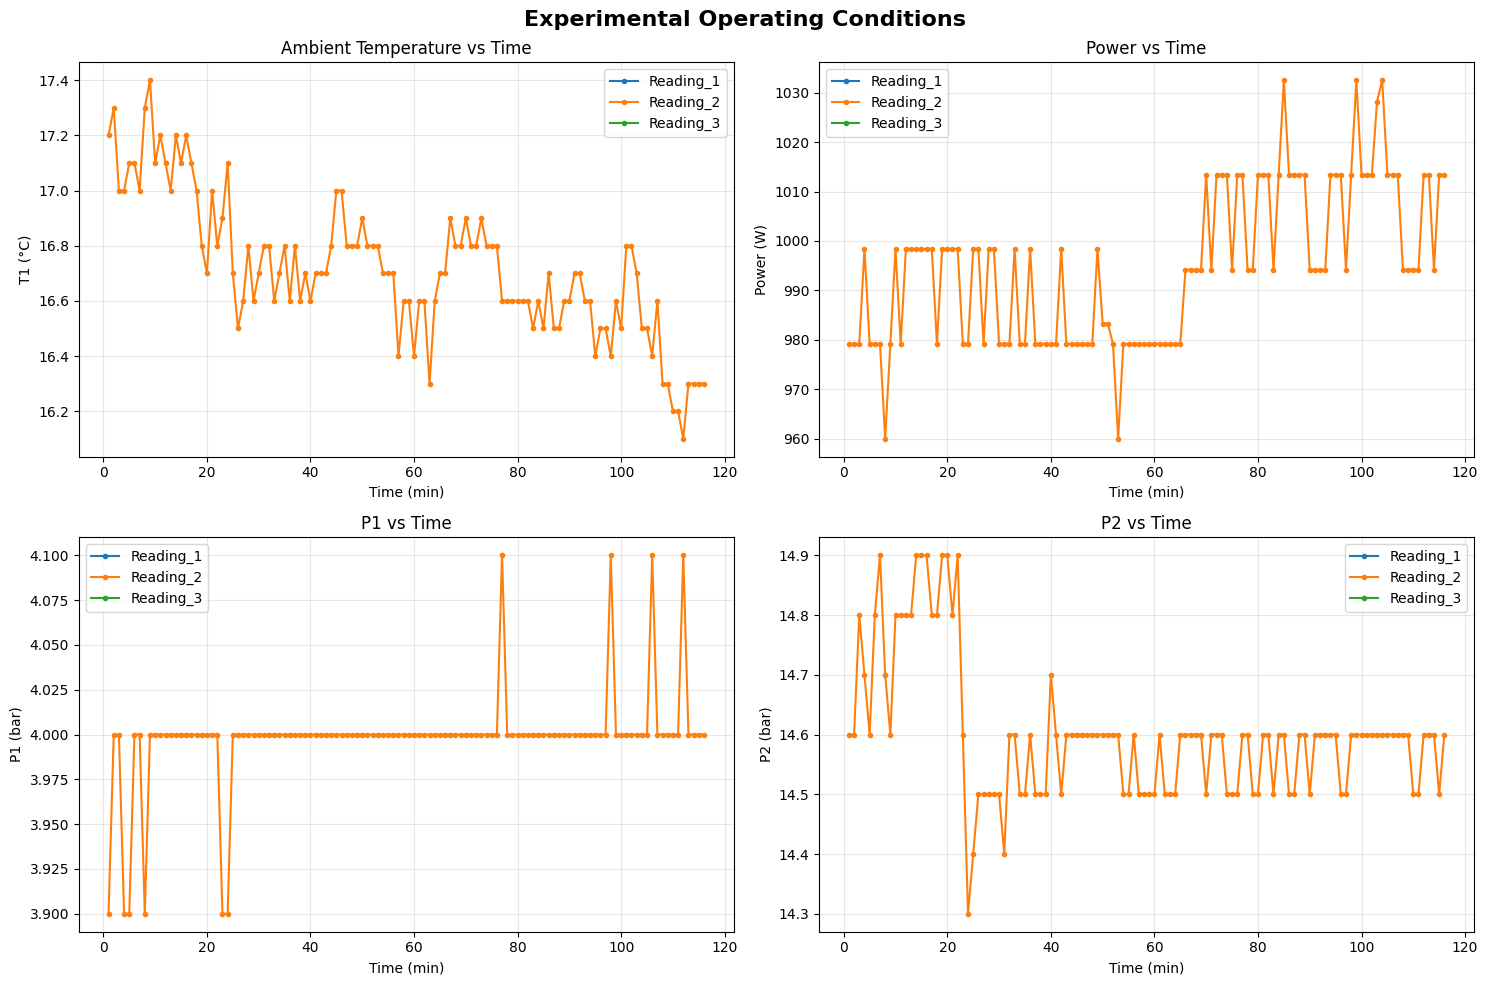

In [6]:
# ============================================================
# CELL 6 — RAW EXPERIMENTAL TRENDS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Ambient temperature
for run, group in data.groupby("Run"):
    axes[0, 0].plot(
        group["Time_min"],
        group["T1_degC"],
        marker="o",
        markersize=3,
        label=run
    )

axes[0, 0].set_title("Ambient Temperature vs Time")
axes[0, 0].set_xlabel("Time (min)")
axes[0, 0].set_ylabel("T1 (°C)")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Power
for run, group in data.groupby("Run"):
    axes[0, 1].plot(
        group["Time_min"],
        group["Power_Watt"],
        marker="o",
        markersize=3,
        label=run
    )

axes[0, 1].set_title("Power vs Time")
axes[0, 1].set_xlabel("Time (min)")
axes[0, 1].set_ylabel("Power (W)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Pressure P1
for run, group in data.groupby("Run"):
    axes[1, 0].plot(
        group["Time_min"],
        group["P1_Bar"],
        marker="o",
        markersize=3,
        label=run
    )

axes[1, 0].set_title("P1 vs Time")
axes[1, 0].set_xlabel("Time (min)")
axes[1, 0].set_ylabel("P1 (bar)")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Pressure P2
for run, group in data.groupby("Run"):
    axes[1, 1].plot(
        group["Time_min"],
        group["P2_Bar"],
        marker="o",
        markersize=3,
        label=run
    )

axes[1, 1].set_title("P2 vs Time")
axes[1, 1].set_xlabel("Time (min)")
axes[1, 1].set_ylabel("P2 (bar)")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle(
    "Experimental Operating Conditions",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

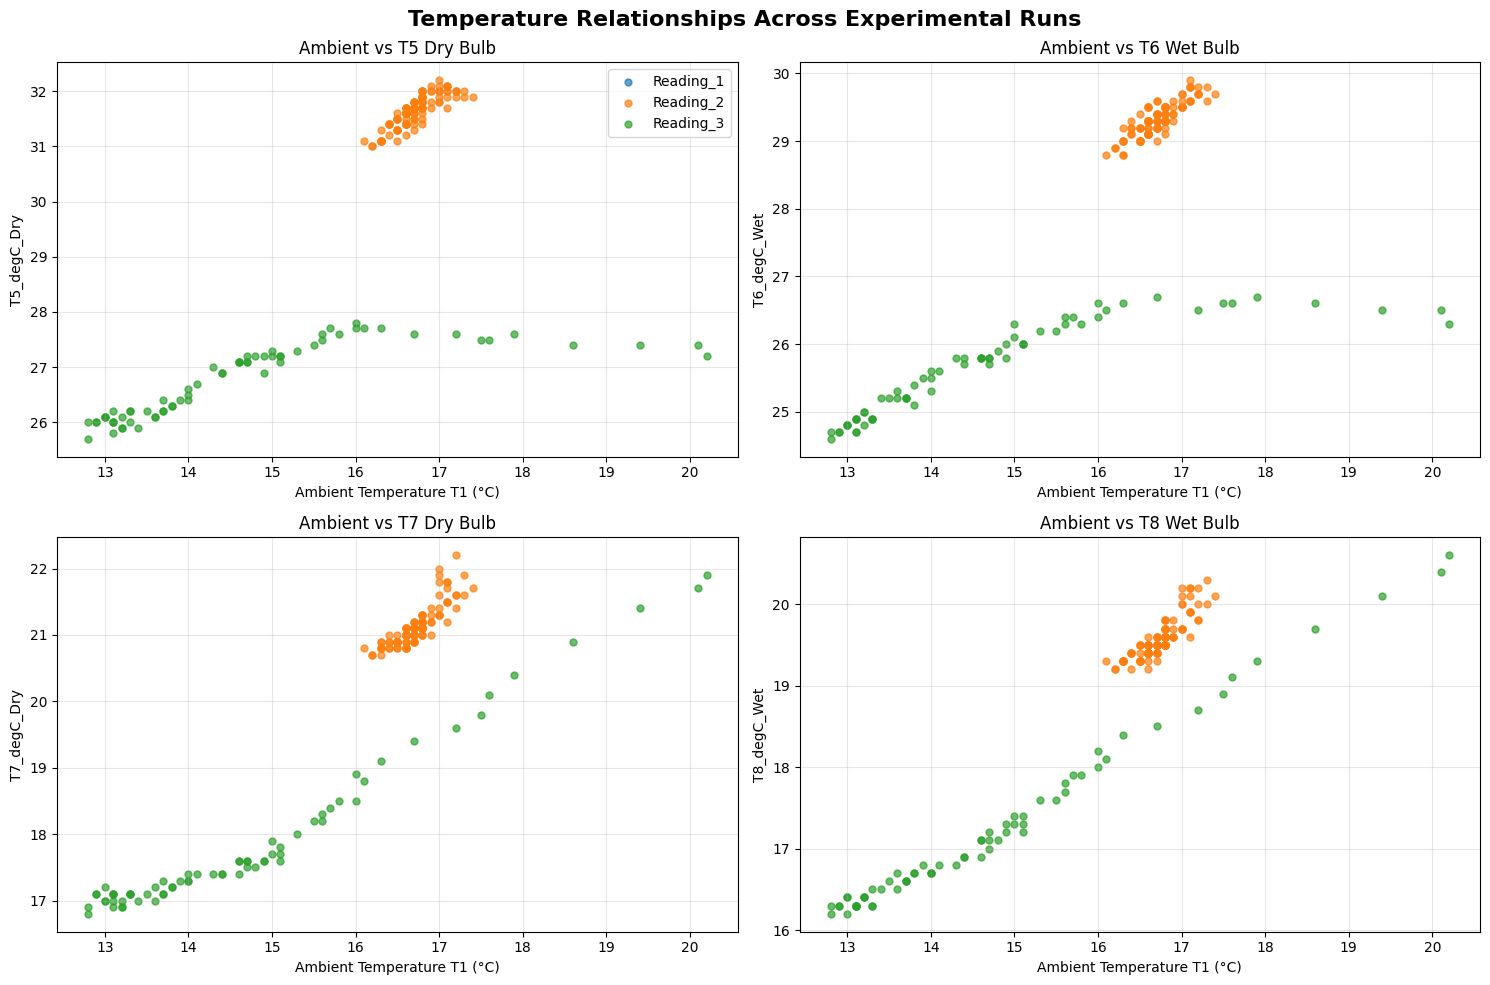

In [7]:
# ============================================================
# CELL 7 — TEMPERATURE MEASUREMENTS
# ============================================================

temperature_columns = [
    "T1_degC",
    "T2_degC",
    "T3_degC",
    "T4_degC",
    "T5_degC_Dry",
    "T6_degC_Wet",
    "T7_degC_Dry",
    "T8_degC_Wet"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_pairs = [
    ("T1_degC", "T5_degC_Dry", "Ambient vs T5 Dry Bulb"),
    ("T1_degC", "T6_degC_Wet", "Ambient vs T6 Wet Bulb"),
    ("T1_degC", "T7_degC_Dry", "Ambient vs T7 Dry Bulb"),
    ("T1_degC", "T8_degC_Wet", "Ambient vs T8 Wet Bulb")
]

for ax, (xcol, ycol, title) in zip(
    axes.flat,
    plot_pairs
):

    for run, group in data.groupby("Run"):
        ax.scatter(
            group[xcol],
            group[ycol],
            s=25,
            alpha=0.7,
            label=run
        )

    ax.set_title(title)
    ax.set_xlabel("Ambient Temperature T1 (°C)")
    ax.set_ylabel(ycol)
    ax.grid(alpha=0.3)

axes[0, 0].legend()

plt.suptitle(
    "Temperature Relationships Across Experimental Runs",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 8 — FINAL DATA STRUCTURE CHECK
# ============================================================

print("=" * 70)
print("FINAL DATA STRUCTURE CHECK")
print("=" * 70)

print("\nDataset shape:")
print(data.shape)

print("\nColumns:")
print(list(data.columns))

print("\nMissing values:")
display(
    data.isnull().sum()
    .sort_values(ascending=False)
    .to_frame("Missing_Values")
)

print("\nUnique experimental runs:")
print(data["Run"].unique())

print("\nNumber of readings per run:")
display(
    data.groupby("Run")
        .size()
        .to_frame("Number_of_Readings")
)

print("\nNumerical columns:")
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
print(numeric_columns)

FINAL DATA STRUCTURE CHECK

Dataset shape:
(255, 28)

Columns:
['1.0', '936.9', '25.2', '59.8', '42.3', '8.6', '34.4', '32.4', '28.1', '25.7', '3.4', '12.9', '2.0', 'Run', 'Time_min', 'Power_Watt', 'T1_degC', 'T2_degC', 'T3_degC', 'T4_degC', 'T5_degC_Dry', 'T6_degC_Wet', 'T7_degC_Dry', 'T8_degC_Wet', 'P1_Bar', 'P2_Bar', 'Air_Velocitym_Sec', 'Time']

Missing values:


,Missing_Values
Time,187
1.0,184
25.2,184
936.9,184
42.3,184
8.6,184
34.4,184
32.4,184
28.1,184
25.7,184



Unique experimental runs:
['Reading_1' 'Reading_2' 'Reading_3']

Number of readings per run:


,Number_of_Readings
Run,
Reading_1,71
Reading_2,116
Reading_3,68



Numerical columns:
['1.0', '936.9', '25.2', '59.8', '42.3', '8.6', '34.4', '32.4', '28.1', '25.7', '3.4', '12.9', '2.0', 'Time_min', 'Power_Watt', 'T1_degC', 'T2_degC', 'T3_degC', 'T4_degC', 'T5_degC_Dry', 'T6_degC_Wet', 'T7_degC_Dry', 'T8_degC_Wet', 'P1_Bar', 'P2_Bar', 'Air_Velocitym_Sec', 'Time']


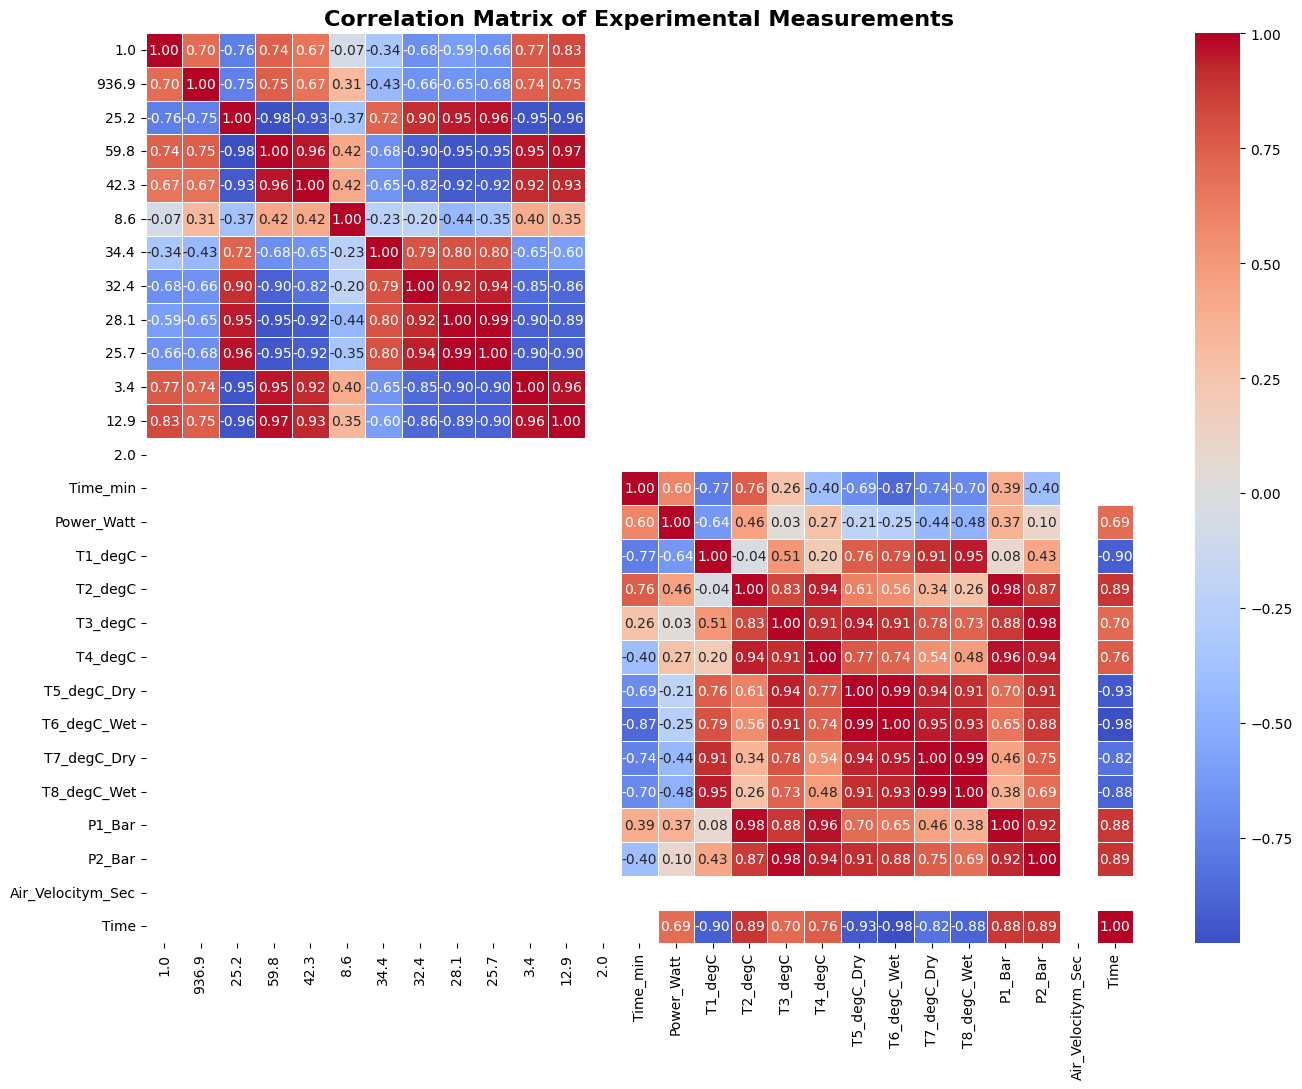

In [9]:
# ============================================================
# CELL 9 — CORRELATION MATRIX
# ============================================================

numeric_data = data.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Experimental Measurements",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 10 — MISSING DATA AND DUPLICATE CHECK
# ============================================================

print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Missing values
missing_summary = (
    data.isnull()
    .sum()
    .to_frame("Missing")
)

missing_summary["Percentage"] = (
    missing_summary["Missing"] /
    len(data) * 100
)

display(missing_summary)

# Duplicate rows
duplicates = data.duplicated().sum()

print("\nDuplicate rows:", duplicates)

# Infinite values
numeric_data = data.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_data).sum().sum()

print("Infinite numerical values:", infinite_values)

DATA QUALITY CHECK


,Missing,Percentage
1.0,184,72.156863
936.9,184,72.156863
25.2,184,72.156863
59.8,184,72.156863
42.3,184,72.156863
8.6,184,72.156863
34.4,184,72.156863
32.4,184,72.156863
28.1,184,72.156863
25.7,184,72.156863



Duplicate rows: 0
Infinite numerical values: 0


In [11]:
# ============================================================
# CELL 11 — DEFINE ML FEATURES AND TARGETS
# ============================================================

input_features = [
    "T1_degC",
    "T2_degC",
    "T3_degC",
    "T4_degC",
    "P1_Bar",
    "P2_Bar",
    "Power_Watt"
]

target_features = [
    "T5_degC_Dry",
    "T6_degC_Wet",
    "T7_degC_Dry",
    "T8_degC_Wet"
]

ml_data = data[
    ["Run", "Time_min"] +
    input_features +
    target_features
].copy()

print("=" * 70)
print("ML DATASET")
print("=" * 70)

print("\nInput features:")
for feature in input_features:
    print(" -", feature)

print("\nTarget variables:")
for target in target_features:
    print(" -", target)

print("\nML dataset shape:", ml_data.shape)

display(ml_data.head())

ML DATASET

Input features:
 - T1_degC
 - T2_degC
 - T3_degC
 - T4_degC
 - P1_Bar
 - P2_Bar
 - Power_Watt

Target variables:
 - T5_degC_Dry
 - T6_degC_Wet
 - T7_degC_Dry
 - T8_degC_Wet

ML dataset shape: (255, 13)


,Run,Time_min,T1_degC,T2_degC,T3_degC,T4_degC,P1_Bar,P2_Bar,Power_Watt,T5_degC_Dry,T6_degC_Wet,T7_degC_Dry,T8_degC_Wet
0,Reading_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Reading_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Reading_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Reading_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Reading_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ============================================================
# CELL 12 — CLEAN ML DATASET
# ============================================================

required_columns = (
    input_features +
    target_features
)

before = len(ml_data)

ml_data = ml_data.dropna(
    subset=required_columns
).reset_index(drop=True)

after = len(ml_data)

print("=" * 70)
print("ML DATA CLEANING")
print("=" * 70)

print("Rows before cleaning :", before)
print("Rows after cleaning  :", after)
print("Rows removed         :", before - after)

print("\nFinal ML dataset:")
display(ml_data.head())

print("\nFinal shape:", ml_data.shape)

ML DATA CLEANING
Rows before cleaning : 255
Rows after cleaning  : 184
Rows removed         : 71

Final ML dataset:


,Run,Time_min,T1_degC,T2_degC,T3_degC,T4_degC,P1_Bar,P2_Bar,Power_Watt,T5_degC_Dry,T6_degC_Wet,T7_degC_Dry,T8_degC_Wet
0,Reading_2,1.0,17.2,81.3,43.6,9.9,3.9,14.6,979.2,31.9,29.7,22.2,20.2
1,Reading_2,2.0,17.3,81.4,44.0,10.1,4.0,14.6,979.2,31.9,29.6,21.9,20.3
2,Reading_2,3.0,17.0,82.9,44.1,10.6,4.0,14.8,979.2,32.0,29.5,22.0,20.2
3,Reading_2,4.0,17.0,83.4,45.5,10.4,3.9,14.7,998.4,32.0,29.5,21.9,20.1
4,Reading_2,5.0,17.1,83.0,44.6,10.3,3.9,14.6,979.2,32.0,29.8,21.8,20.2



Final shape: (184, 13)


In [13]:
# ============================================================
# CELL 13 — EXPERIMENTAL GROUP DISTRIBUTION
# ============================================================

print("=" * 70)
print("EXPERIMENTAL GROUP DISTRIBUTION")
print("=" * 70)

group_summary = ml_data.groupby("Run").agg(
    Samples=("Run", "size"),
    T1_Min=("T1_degC", "min"),
    T1_Max=("T1_degC", "max"),
    T1_Mean=("T1_degC", "mean"),
    Power_Min=("Power_Watt", "min"),
    Power_Max=("Power_Watt", "max")
)

display(group_summary)

EXPERIMENTAL GROUP DISTRIBUTION


,Samples,T1_Min,T1_Max,T1_Mean,Power_Min,Power_Max
Run,,,,,,
Reading_2,116,16.1,17.4,16.718103,960.0,1032.5
Reading_3,68,12.8,20.2,14.738235,894.9,1042.8


In [14]:
# ============================================================
# CELL 14 — VALIDATION STRATEGY
# ============================================================

print("=" * 70)
print("VALIDATION STRATEGY")
print("=" * 70)

print("""
The dataset contains multiple sequential measurements
from the same experimental runs.

Therefore, randomly splitting individual rows can place
very similar measurements in both training and testing data.

To reduce this risk, validation will be performed using
the experimental RUN as the grouping variable.

Each validation fold will hold out an entire experimental
run and train on the remaining runs.

This provides a more realistic estimate of model
generalization to a new experimental condition.
""")

print("Number of experimental groups:", ml_data["Run"].nunique())
print("Groups:", ml_data["Run"].unique())

VALIDATION STRATEGY

The dataset contains multiple sequential measurements
from the same experimental runs.

Therefore, randomly splitting individual rows can place
very similar measurements in both training and testing data.

To reduce this risk, validation will be performed using
the experimental RUN as the grouping variable.

Each validation fold will hold out an entire experimental
run and train on the remaining runs.

This provides a more realistic estimate of model
generalization to a new experimental condition.

Number of experimental groups: 2
Groups: ['Reading_2' 'Reading_3']


In [15]:
# ============================================================
# CELL 15 — PREPARE X AND Y
# ============================================================

X = ml_data[input_features].copy()
Y = ml_data[target_features].copy()
groups = ml_data["Run"].copy()

print("=" * 70)
print("ML MATRICES")
print("=" * 70)

print("\nX shape:", X.shape)
print("Y shape:", Y.shape)

print("\nX:")
display(X.head())

print("\nY:")
display(Y.head())

print("\nGroups:")
print(groups.value_counts())

ML MATRICES

X shape: (184, 7)
Y shape: (184, 4)

X:


,T1_degC,T2_degC,T3_degC,T4_degC,P1_Bar,P2_Bar,Power_Watt
0,17.2,81.3,43.6,9.9,3.9,14.6,979.2
1,17.3,81.4,44.0,10.1,4.0,14.6,979.2
2,17.0,82.9,44.1,10.6,4.0,14.8,979.2
3,17.0,83.4,45.5,10.4,3.9,14.7,998.4
4,17.1,83.0,44.6,10.3,3.9,14.6,979.2



Y:


,T5_degC_Dry,T6_degC_Wet,T7_degC_Dry,T8_degC_Wet
0,31.9,29.7,22.2,20.2
1,31.9,29.6,21.9,20.3
2,32.0,29.5,22.0,20.2
3,32.0,29.5,21.9,20.1
4,32.0,29.8,21.8,20.2



Groups:
Run
Reading_2    116
Reading_3     68
Name: count, dtype: int64


In [16]:
# ============================================================
# CELL 16 — BASELINE MODEL
# ============================================================

from sklearn.dummy import DummyRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

baseline_predictions = np.zeros_like(Y.values, dtype=float)

for train_idx, test_idx in logo.split(X, Y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    Y_train = Y.iloc[train_idx]

    baseline = DummyRegressor(
        strategy="mean"
    )

    baseline.fit(X_train, Y_train)

    baseline_predictions[test_idx] = baseline.predict(X_test)

baseline_results = []

for i, target in enumerate(target_features):

    actual = Y.iloc[:, i]

    predicted = baseline_predictions[:, i]

    baseline_results.append({
        "Target": target,
        "R2": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    })

baseline_df = pd.DataFrame(baseline_results)

display(
    baseline_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

,Target,R2,MAE,RMSE
0,T5_degC_Dry,-3.1750,4.8765,4.8974
1,T6_degC_Wet,-3.1009,3.6793,3.7056
2,T7_degC_Dry,-2.6468,3.2534,3.3263
3,T8_degC_Wet,-2.4199,2.3411,2.4085


In [17]:
# ============================================================
# CELL 17 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_predictions = np.zeros_like(Y.values, dtype=float)

for train_idx, test_idx in logo.split(X, Y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    Y_train = Y.iloc[train_idx]

    model_rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model_rf.fit(
        X_train,
        Y_train
    )

    rf_predictions[test_idx] = model_rf.predict(X_test)

rf_results = []

for i, target in enumerate(target_features):

    actual = Y.iloc[:, i]
    predicted = rf_predictions[:, i]

    rf_results.append({
        "Target": target,
        "R2": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    })

rf_df = pd.DataFrame(rf_results)

print("=" * 70)
print("RANDOM FOREST — GROUPED CROSS-VALIDATION")
print("=" * 70)

display(
    rf_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

RANDOM FOREST — GROUPED CROSS-VALIDATION


,Target,R2,MAE,RMSE
0,T5_degC_Dry,-2.6770,4.5754,4.5960
1,T6_degC_Wet,-2.5834,3.4419,3.4640
2,T7_degC_Dry,-2.5058,3.2051,3.2613
3,T8_degC_Wet,-2.1281,2.2455,2.3034


In [18]:
# ============================================================
# CELL 18 — EXTRA TREES REGRESSION
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor

et_predictions = np.zeros_like(Y.values, dtype=float)

for train_idx, test_idx in logo.split(X, Y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    Y_train = Y.iloc[train_idx]

    model_et = ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model_et.fit(
        X_train,
        Y_train
    )

    et_predictions[test_idx] = model_et.predict(X_test)

et_results = []

for i, target in enumerate(target_features):

    actual = Y.iloc[:, i]
    predicted = et_predictions[:, i]

    et_results.append({
        "Target": target,
        "R2": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    })

et_df = pd.DataFrame(et_results)

print("=" * 70)
print("EXTRA TREES — GROUPED CROSS-VALIDATION")
print("=" * 70)

display(
    et_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

EXTRA TREES — GROUPED CROSS-VALIDATION


,Target,R2,MAE,RMSE
0,T5_degC_Dry,-3.1224,4.8461,4.8664
1,T6_degC_Wet,-3.1764,3.7171,3.7396
2,T7_degC_Dry,-3.2753,3.5420,3.6015
3,T8_degC_Wet,-3.0464,2.5599,2.6198


In [19]:
# ============================================================
# CELL 19 — GRADIENT BOOSTING REGRESSION
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gbr_predictions = np.zeros_like(Y.values, dtype=float)

for train_idx, test_idx in logo.split(X, Y, groups):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    Y_train = Y.iloc[train_idx]

    model_gbr = MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=2,
            min_samples_leaf=2,
            random_state=42
        )
    )

    model_gbr.fit(X_train, Y_train)

    gbr_predictions[test_idx] = model_gbr.predict(X_test)


gbr_results = []

for i, target in enumerate(target_features):

    actual = Y.iloc[:, i]
    predicted = gbr_predictions[:, i]

    gbr_results.append({
        "Target": target,
        "R2": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    })

gbr_df = pd.DataFrame(gbr_results)

print("=" * 70)
print("GRADIENT BOOSTING — GROUPED CROSS-VALIDATION")
print("=" * 70)

display(
    gbr_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

GRADIENT BOOSTING — GROUPED CROSS-VALIDATION


,Target,R2,MAE,RMSE
0,T5_degC_Dry,-2.6850,4.5797,4.6010
1,T6_degC_Wet,-3.3461,3.7918,3.8149
2,T7_degC_Dry,-2.7434,3.3049,3.3700
3,T8_degC_Wet,-2.2744,2.2930,2.3567


In [20]:
# ============================================================
# CELL 20 — POLYNOMIAL RIDGE REGRESSION
# ============================================================

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

poly_predictions = np.zeros_like(Y.values, dtype=float)

for train_idx, test_idx in logo.split(X, Y, groups):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    Y_train = Y.iloc[train_idx]

    poly_model = Pipeline([
        (
            "polynomial",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(alpha=1.0)
        )
    ])

    poly_model = MultiOutputRegressor(
        poly_model
    )

    poly_model.fit(
        X_train,
        Y_train
    )

    poly_predictions[test_idx] = (
        poly_model.predict(X_test)
    )


poly_results = []

for i, target in enumerate(target_features):

    actual = Y.iloc[:, i]
    predicted = poly_predictions[:, i]

    poly_results.append({
        "Target": target,
        "R2": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    })

poly_df = pd.DataFrame(poly_results)

print("=" * 70)
print("POLYNOMIAL RIDGE — GROUPED CROSS-VALIDATION")
print("=" * 70)

display(
    poly_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

POLYNOMIAL RIDGE — GROUPED CROSS-VALIDATION


,Target,R2,MAE,RMSE
0,T5_degC_Dry,0.6600,1.3230,1.3976
1,T6_degC_Wet,-1.0521,2.5963,2.6214
2,T7_degC_Dry,-3.3694,3.5974,3.6409
3,T8_degC_Wet,-2.8728,2.5151,2.5630


In [21]:
# ============================================================
# CELL 21 — SUPPORT VECTOR REGRESSION
# ============================================================

from sklearn.svm import SVR

svr_predictions = np.zeros_like(Y.values, dtype=float)

for train_idx, test_idx in logo.split(X, Y, groups):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    Y_train = Y.iloc[train_idx]

    svr_base = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svr",
            SVR(
                kernel="rbf",
                C=100,
                gamma="scale",
                epsilon=0.01
            )
        )
    ])

    model_svr = MultiOutputRegressor(
        svr_base
    )

    model_svr.fit(
        X_train,
        Y_train
    )

    svr_predictions[test_idx] = (
        model_svr.predict(X_test)
    )


svr_results = []

for i, target in enumerate(target_features):

    actual = Y.iloc[:, i]
    predicted = svr_predictions[:, i]

    svr_results.append({
        "Target": target,
        "R2": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    })

svr_df = pd.DataFrame(svr_results)

print("=" * 70)
print("SVR — GROUPED CROSS-VALIDATION")
print("=" * 70)

display(
    svr_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

SVR — GROUPED CROSS-VALIDATION


,Target,R2,MAE,RMSE
0,T5_degC_Dry,-3.1755,4.8762,4.8976
1,T6_degC_Wet,-3.0227,3.6388,3.6702
2,T7_degC_Dry,-1.5920,2.6278,2.8042
3,T8_degC_Wet,-1.4898,1.9175,2.0550


In [22]:
# ============================================================
# CELL 22 — COMPLETE MODEL COMPARISON
# ============================================================

all_model_results = []

model_tables = {
    "Baseline": baseline_df,
    "Random Forest": rf_df,
    "Extra Trees": et_df,
    "Gradient Boosting": gbr_df,
    "Polynomial Ridge": poly_df,
    "SVR": svr_df
}

for model_name, result_df in model_tables.items():

    temp = result_df.copy()
    temp["Model"] = model_name

    all_model_results.append(temp)

comparison_df = pd.concat(
    all_model_results,
    ignore_index=True
)

comparison_df = comparison_df[
    [
        "Model",
        "Target",
        "R2",
        "MAE",
        "RMSE"
    ]
]

print("=" * 80)
print("COMPLETE MODEL BENCHMARK — GROUPED CROSS-VALIDATION")
print("=" * 80)

display(
    comparison_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

COMPLETE MODEL BENCHMARK — GROUPED CROSS-VALIDATION


,Model,Target,R2,MAE,RMSE
0,Baseline,T5_degC_Dry,-3.1750,4.8765,4.8974
1,Baseline,T6_degC_Wet,-3.1009,3.6793,3.7056
2,Baseline,T7_degC_Dry,-2.6468,3.2534,3.3263
3,Baseline,T8_degC_Wet,-2.4199,2.3411,2.4085
4,Random Forest,T5_degC_Dry,-2.6770,4.5754,4.5960
5,Random Forest,T6_degC_Wet,-2.5834,3.4419,3.4640
6,Random Forest,T7_degC_Dry,-2.5058,3.2051,3.2613
7,Random Forest,T8_degC_Wet,-2.1281,2.2455,2.3034
8,Extra Trees,T5_degC_Dry,-3.1224,4.8461,4.8664
9,Extra Trees,T6_degC_Wet,-3.1764,3.7171,3.7396


In [23]:
# ============================================================
# CELL 23 — MODEL-LEVEL SUMMARY
# ============================================================

model_summary = (
    comparison_df
    .groupby("Model")
    .agg(
        Mean_R2=("R2", "mean"),
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean")
    )
    .sort_values(
        "Mean_R2",
        ascending=False
    )
)

print("=" * 70)
print("MODEL-LEVEL PERFORMANCE SUMMARY")
print("=" * 70)

display(
    model_summary.style.format({
        "Mean_R2": "{:.4f}",
        "Mean_MAE": "{:.4f}",
        "Mean_RMSE": "{:.4f}"
    })
)

MODEL-LEVEL PERFORMANCE SUMMARY


,Mean_R2,Mean_MAE,Mean_RMSE
Model,,,
Polynomial Ridge,-1.6586,2.5079,2.5557
SVR,-2.3200,3.2651,3.3568
Random Forest,-2.4736,3.3670,3.4062
Gradient Boosting,-2.7622,3.4923,3.5356
Baseline,-2.8356,3.5376,3.5844
Extra Trees,-3.1551,3.6663,3.7068


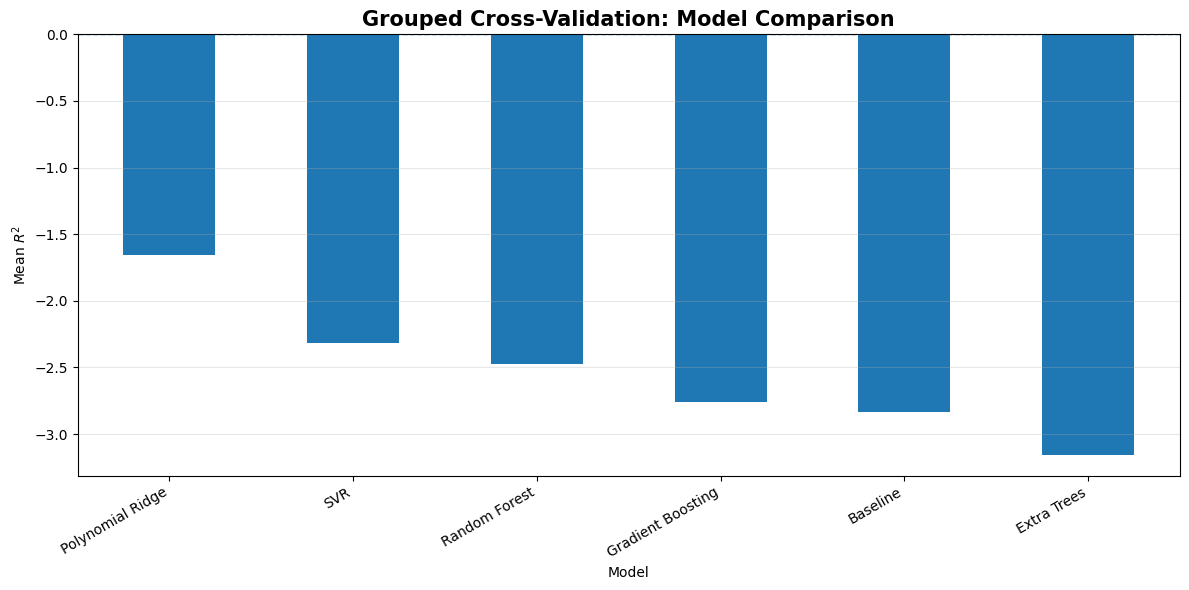

In [24]:
# ============================================================
# CELL 24 — MODEL PERFORMANCE COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

model_summary["Mean_R2"].plot(
    kind="bar"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.ylabel(r"Mean $R^2$")
plt.xlabel("Model")
plt.title(
    "Grouped Cross-Validation: Model Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL 25 — RANDOM ROW-WISE CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import KFold, cross_val_predict

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rowwise_predictions = {}

for model_name, estimator in [

    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    ),

    (
        "Extra Trees",
        ExtraTreesRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    ),

    (
        "Gradient Boosting",
        MultiOutputRegressor(
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.03,
                max_depth=2,
                random_state=42
            )
        )
    ),

    (
        "Polynomial Ridge",
        MultiOutputRegressor(
            Pipeline([
                (
                    "poly",
                    PolynomialFeatures(
                        degree=2,
                        include_bias=False
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "ridge",
                    Ridge(alpha=1.0)
                )
            ])
        )
    )
]:

    prediction = cross_val_predict(
        estimator,
        X,
        Y,
        cv=kf,
        n_jobs=None
    )

    rowwise_predictions[model_name] = prediction


rowwise_results = []

for model_name, prediction in rowwise_predictions.items():

    for i, target in enumerate(target_features):

        actual = Y.iloc[:, i]
        predicted = prediction[:, i]

        rowwise_results.append({
            "Model": model_name,
            "Target": target,
            "R2": r2_score(actual, predicted),
            "MAE": mean_absolute_error(
                actual,
                predicted
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    actual,
                    predicted
                )
            )
        })

rowwise_df = pd.DataFrame(
    rowwise_results
)

print("=" * 80)
print("ROW-WISE INTERPOLATION VALIDATION")
print("=" * 80)

display(
    rowwise_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

ROW-WISE INTERPOLATION VALIDATION


,Model,Target,R2,MAE,RMSE
0,Random Forest,T5_degC_Dry,0.9964,0.1047,0.1429
1,Random Forest,T6_degC_Wet,0.9953,0.0947,0.1253
2,Random Forest,T7_degC_Dry,0.9924,0.0986,0.1516
3,Random Forest,T8_degC_Wet,0.9910,0.0844,0.1233
4,Extra Trees,T5_degC_Dry,0.9972,0.0973,0.1273
5,Extra Trees,T6_degC_Wet,0.9960,0.0923,0.1160
6,Extra Trees,T7_degC_Dry,0.9952,0.0854,0.1208
7,Extra Trees,T8_degC_Wet,0.9942,0.0749,0.0996
8,Gradient Boosting,T5_degC_Dry,0.9970,0.1064,0.1305
9,Gradient Boosting,T6_degC_Wet,0.9958,0.0947,0.1191


In [26]:
# ============================================================
# CELL 26 — VALIDATION STRATEGY COMPARISON
# ============================================================

runwise_summary = (
    comparison_df
    .groupby("Model")
    .agg(
        Runwise_R2=("R2", "mean"),
        Runwise_MAE=("MAE", "mean"),
        Runwise_RMSE=("RMSE", "mean")
    )
)

rowwise_summary = (
    rowwise_df
    .groupby("Model")
    .agg(
        Rowwise_R2=("R2", "mean"),
        Rowwise_MAE=("MAE", "mean"),
        Rowwise_RMSE=("RMSE", "mean")
    )
)

validation_comparison = runwise_summary.join(
    rowwise_summary,
    how="inner"
)

print("=" * 90)
print("RUN-WISE VS ROW-WISE VALIDATION")
print("=" * 90)

display(
    validation_comparison.style.format(
        "{:.4f}"
    )
)

RUN-WISE VS ROW-WISE VALIDATION


,Runwise_R2,Runwise_MAE,Runwise_RMSE,Rowwise_R2,Rowwise_MAE,Rowwise_RMSE
Model,,,,,,
Extra Trees,-3.1551,3.6663,3.7068,0.9956,0.0875,0.1159
Gradient Boosting,-2.7622,3.4923,3.5356,0.9887,0.1095,0.1677
Polynomial Ridge,-1.6586,2.5079,2.5557,0.9935,0.1117,0.1415
Random Forest,-2.4736,3.3670,3.4062,0.9938,0.0956,0.1358


In [27]:
# ============================================================
# CELL 27 — EXPERIMENTAL STRUCTURE AUDIT
# ============================================================

print("=" * 75)
print("EXPERIMENTAL STRUCTURE AUDIT")
print("=" * 75)

print("\nDataset shape:")
print(data.shape)

print("\nColumns:")
for i, col in enumerate(data.columns):
    print(f"{i:02d} -> {col}")

print("\nMissing values:")
display(
    data.isnull().sum()
    .sort_values(ascending=False)
    .to_frame("Missing_Count")
)

print("\nUnique values per column:")
unique_info = pd.DataFrame({
    "Column": data.columns,
    "Unique_Values": [
        data[c].nunique()
        for c in data.columns
    ]
})

display(unique_info)

print("\nBasic statistics:")
display(data.describe().T)

EXPERIMENTAL STRUCTURE AUDIT

Dataset shape:
(255, 28)

Columns:
00 -> 1.0
01 -> 936.9
02 -> 25.2
03 -> 59.8
04 -> 42.3
05 -> 8.6
06 -> 34.4
07 -> 32.4
08 -> 28.1
09 -> 25.7
10 -> 3.4
11 -> 12.9
12 -> 2.0
13 -> Run
14 -> Time_min
15 -> Power_Watt
16 -> T1_degC
17 -> T2_degC
18 -> T3_degC
19 -> T4_degC
20 -> T5_degC_Dry
21 -> T6_degC_Wet
22 -> T7_degC_Dry
23 -> T8_degC_Wet
24 -> P1_Bar
25 -> P2_Bar
26 -> Air_Velocitym_Sec
27 -> Time

Missing values:


,Missing_Count
Time,187
1.0,184
25.2,184
936.9,184
42.3,184
8.6,184
34.4,184
32.4,184
28.1,184
25.7,184



Unique values per column:


,Column,Unique_Values
0,1.0,71
1,936.9,8
2,25.2,26
3,59.8,41
4,42.3,24
5,8.6,15
6,34.4,13
7,32.4,11
8,28.1,18
9,25.7,19



Basic statistics:


,count,mean,std,min,25%,50%,75%,max
1.0,71.0,37.000000,20.639767,2.0,19.500,37.00,54.50,72.0
936.9,71.0,1000.860563,17.423969,936.9,994.200,998.40,1013.40,1032.5
25.2,71.0,19.769014,0.965341,18.7,19.250,19.40,19.90,23.6
59.8,71.0,86.259155,5.144778,66.2,86.400,88.40,89.15,89.7
42.3,71.0,48.681690,1.090257,44.6,48.600,49.00,49.25,49.8
8.6,71.0,12.715493,0.381968,10.9,12.550,12.80,12.90,13.3
34.4,71.0,34.501408,0.247555,34.0,34.400,34.50,34.60,35.2
32.4,71.0,31.935211,0.341885,31.5,31.700,31.80,31.90,32.9
28.1,71.0,23.894366,0.934557,23.2,23.450,23.60,23.70,27.3
25.7,71.0,22.201408,0.846082,21.4,21.800,21.90,22.10,25.0


AMBIENT TEMPERATURE CONDITION ANALYSIS

Number of unique ambient-temperature values:
49

Ambient temperature range:
12.800 °C → 20.200 °C

Ambient temperature distribution:


,Ambient_Temperature,Number_of_Readings
0,12.8,2
1,12.9,2
2,13.0,3
3,13.1,5
4,13.2,3
5,13.3,3
6,13.4,1
7,13.5,1
8,13.6,2
9,13.7,3


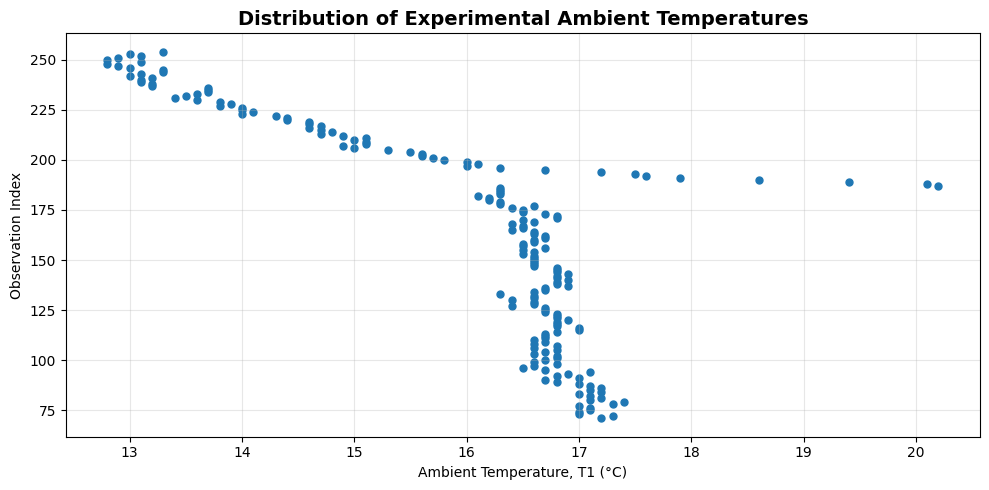

In [28]:
# ============================================================
# CELL 28 — AMBIENT TEMPERATURE CONDITION ANALYSIS
# ============================================================

temp_col = "T1_degC"

print("=" * 75)
print("AMBIENT TEMPERATURE CONDITION ANALYSIS")
print("=" * 75)

print("\nNumber of unique ambient-temperature values:")
print(data[temp_col].nunique())

print("\nAmbient temperature range:")
print(
    f"{data[temp_col].min():.3f} °C"
    f" → "
    f"{data[temp_col].max():.3f} °C"
)

print("\nAmbient temperature distribution:")

temp_summary = (
    data[temp_col]
    .round(2)
    .value_counts()
    .sort_index()
    .rename_axis("Ambient_Temperature")
    .reset_index(name="Number_of_Readings")
)

display(temp_summary)

plt.figure(figsize=(10, 5))

plt.scatter(
    data[temp_col],
    np.arange(len(data)),
    s=25
)

plt.xlabel("Ambient Temperature, T1 (°C)")
plt.ylabel("Observation Index")

plt.title(
    "Distribution of Experimental Ambient Temperatures",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# CELL 29 — REPEATED EXPERIMENT / CONDITION CHECK
# ============================================================

group_candidates = [
    "T1_degC",
    "Power_Watt",
    "P1_Bar",
    "P2_Bar"
]

available_groups = [
    c for c in group_candidates
    if c in data.columns
]

print("=" * 75)
print("REPEATED OPERATING CONDITION CHECK")
print("=" * 75)

print("\nCandidate operating-condition variables:")
print(available_groups)

for col in available_groups:

    print("\n" + "-" * 60)
    print(col)

    print(
        "Unique:",
        data[col].nunique()
    )

    print(
        "Range:",
        data[col].min(),
        "→",
        data[col].max()
    )

REPEATED OPERATING CONDITION CHECK

Candidate operating-condition variables:
['T1_degC', 'Power_Watt', 'P1_Bar', 'P2_Bar']

------------------------------------------------------------
T1_degC
Unique: 49
Range: 12.8 → 20.2

------------------------------------------------------------
Power_Watt
Unique: 19
Range: 894.9 → 1042.8

------------------------------------------------------------
P1_Bar
Unique: 12
Range: 3.0 → 4.1

------------------------------------------------------------
P2_Bar
Unique: 27
Range: 10.6 → 14.9


In [30]:
# ============================================================
# CELL 30 — TIME-SERIES / STEADY-STATE AUDIT
# ============================================================

print("=" * 80)
print("TIME-SERIES AND STEADY-STATE AUDIT")
print("=" * 80)

print("\nDataset shape:")
print(data.shape)

print("\nTime range:")

if "Time_min" in data.columns:
    print(
        f"{data['Time_min'].min():.2f} → "
        f"{data['Time_min'].max():.2f} min"
    )

    print("\nTime monotonicity:")
    print(
        "Increasing:",
        data["Time_min"].is_monotonic_increasing
    )

print("\nSelected variable ranges:")

check_cols = [
    "T1_degC",
    "Power_Watt",
    "P1_Bar",
    "P2_Bar",
    "T5_degC_Dry",
    "T6_degC_Wet",
    "T7_degC_Dry",
    "T8_degC_Wet"
]

for col in check_cols:
    if col in data.columns:
        print(
            f"{col:18s}: "
            f"{data[col].min():.3f} → "
            f"{data[col].max():.3f}"
        )

TIME-SERIES AND STEADY-STATE AUDIT

Dataset shape:
(255, 28)

Time range:
1.00 → 116.00 min

Time monotonicity:
Increasing: False

Selected variable ranges:
T1_degC           : 12.800 → 20.200
Power_Watt        : 894.900 → 1042.800
P1_Bar            : 3.000 → 4.100
P2_Bar            : 10.600 → 14.900
T5_degC_Dry       : 25.700 → 32.200
T6_degC_Wet       : 24.600 → 29.900
T7_degC_Dry       : 16.800 → 22.200
T8_degC_Wet       : 16.200 → 20.600


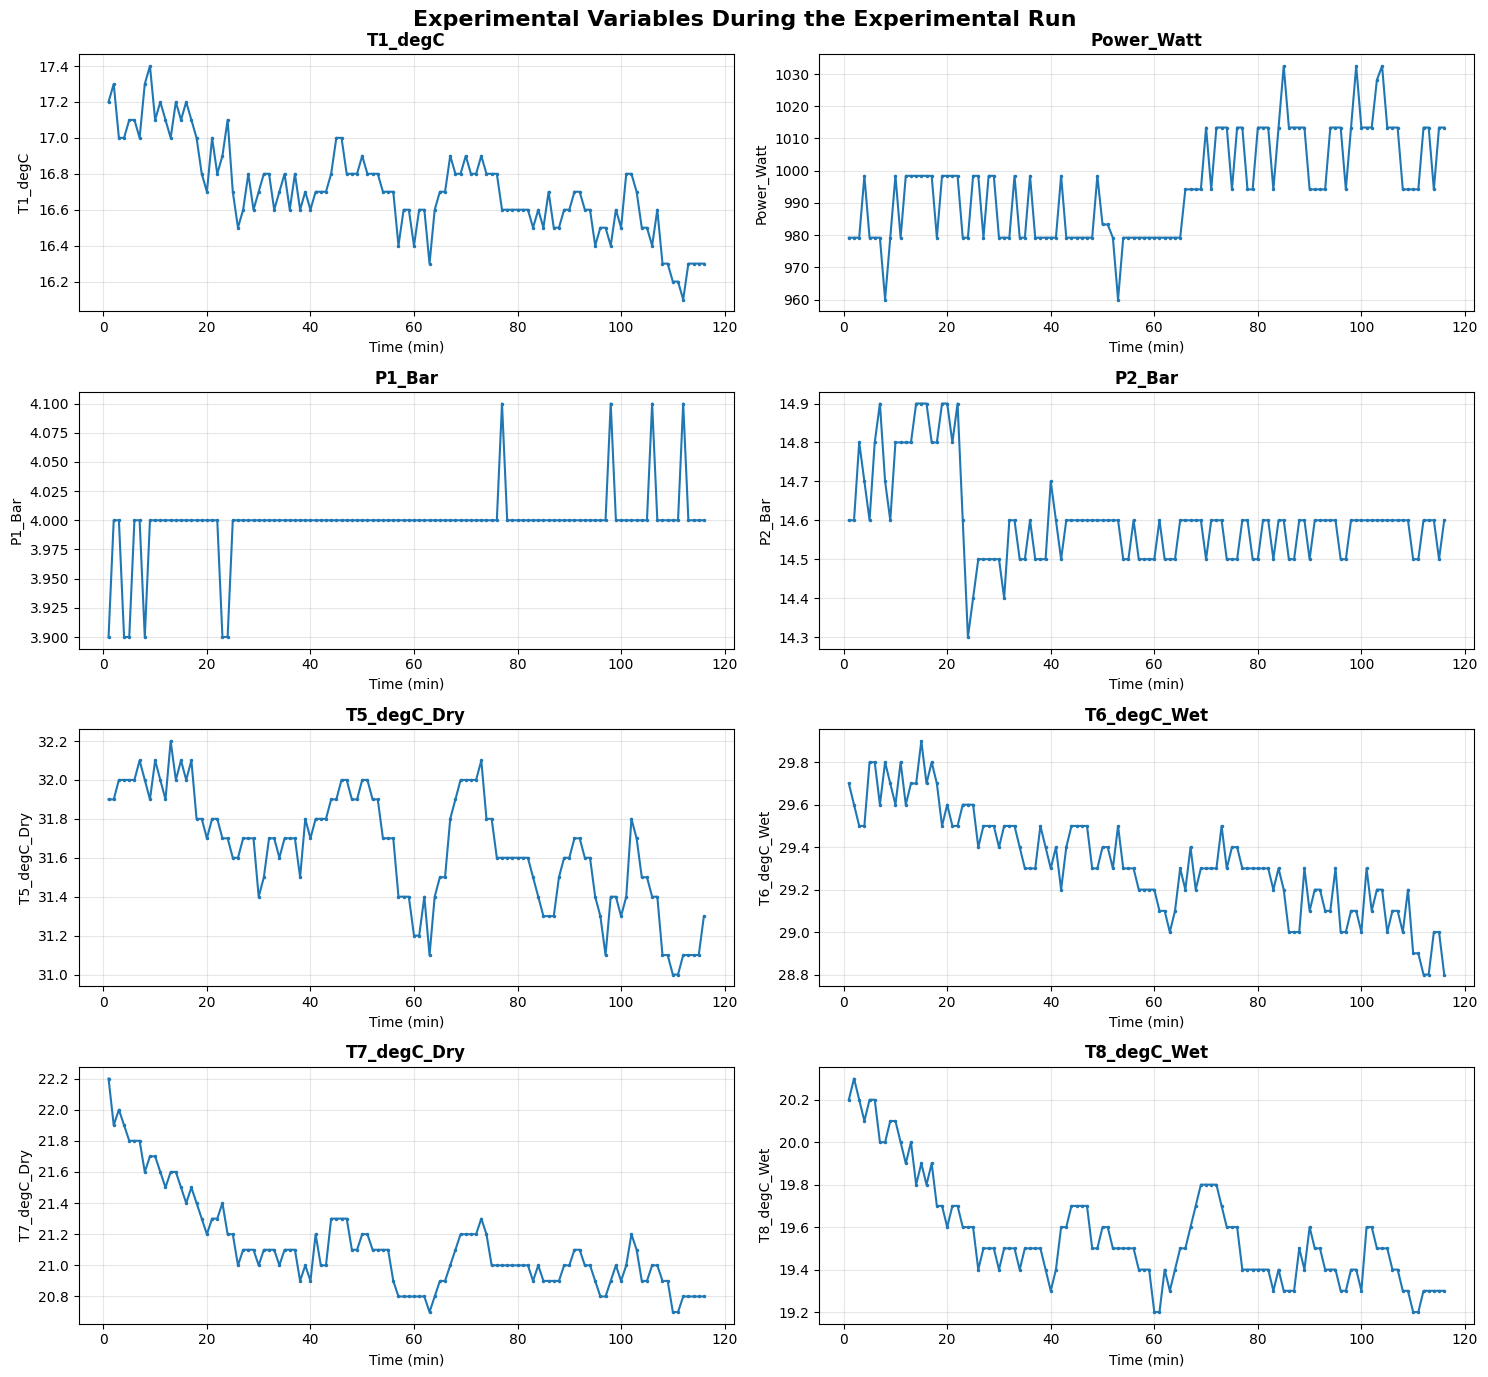

In [31]:
# ============================================================
# CELL 31 — OPERATING VARIABLES VS TIME
# ============================================================

plot_cols = [
    "T1_degC",
    "Power_Watt",
    "P1_Bar",
    "P2_Bar",
    "T5_degC_Dry",
    "T6_degC_Wet",
    "T7_degC_Dry",
    "T8_degC_Wet"
]

available_cols = [
    c for c in plot_cols
    if c in data.columns
]

fig, axes = plt.subplots(
    4, 2,
    figsize=(15, 14)
)

axes = axes.flatten()

for ax, col in zip(axes, available_cols):

    ax.plot(
        data["Time_min"],
        data[col],
        linewidth=1.5,
        marker=".",
        markersize=3
    )

    ax.set_title(
        col,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Time (min)")
    ax.set_ylabel(col)

    ax.grid(
        alpha=0.3
    )

plt.suptitle(
    "Experimental Variables During the Experimental Run",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# CELL 32 — RATE-OF-CHANGE / STABILITY ANALYSIS
# ============================================================

stable_cols = [
    "T1_degC",
    "Power_Watt",
    "P1_Bar",
    "P2_Bar",
    "T5_degC_Dry",
    "T6_degC_Wet",
    "T7_degC_Dry",
    "T8_degC_Wet"
]

stable_cols = [
    c for c in stable_cols
    if c in data.columns
]

stability_df = data[
    ["Time_min"] + stable_cols
].copy()

dt = stability_df["Time_min"].diff()

for col in stable_cols:

    stability_df[f"{col}_rate"] = (
        stability_df[col].diff() / dt
    )

rate_summary = []

for col in stable_cols:

    rate = stability_df[f"{col}_rate"].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    rate_summary.append({
        "Variable": col,
        "Mean_Absolute_Rate": rate.abs().mean(),
        "Median_Absolute_Rate": rate.abs().median(),
        "Maximum_Absolute_Rate": rate.abs().max()
    })

rate_summary_df = pd.DataFrame(
    rate_summary
)

print("=" * 80)
print("RATE-OF-CHANGE ANALYSIS")
print("=" * 80)

display(
    rate_summary_df.style.format({
        "Mean_Absolute_Rate": "{:.6f}",
        "Median_Absolute_Rate": "{:.6f}",
        "Maximum_Absolute_Rate": "{:.6f}"
    })
)

RATE-OF-CHANGE ANALYSIS


,Variable,Mean_Absolute_Rate,Median_Absolute_Rate,Maximum_Absolute_Rate
0,T1_degC,0.108696,0.100000,0.400000
1,Power_Watt,7.972174,0.000000,19.200000
2,P1_Bar,0.013043,0.000000,0.100000
3,P2_Bar,0.052174,0.000000,0.300000
4,T5_degC_Dry,0.090435,0.100000,0.400000
5,T6_degC_Wet,0.094783,0.100000,0.300000
6,T7_degC_Dry,0.069565,0.100000,0.300000
7,T8_degC_Wet,0.063478,0.100000,0.300000


In [33]:
# ============================================================
# CELL 33 — AMBIENT TEMPERATURE GROUPS
# ============================================================

temperature_col = "T1_degC"

# Create 5 approximately equal-sized temperature groups
data["Temperature_Group"] = pd.qcut(
    data[temperature_col],
    q=5,
    labels=False,
    duplicates="drop"
)

print("=" * 80)
print("AMBIENT TEMPERATURE GROUPING")
print("=" * 80)

temperature_groups = (
    data.groupby("Temperature_Group")
    .agg(
        Samples=(temperature_col, "size"),
        Tmin=(temperature_col, "min"),
        Tmax=(temperature_col, "max"),
        Tmean=(temperature_col, "mean")
    )
    .reset_index()
)

display(
    temperature_groups.style.format({
        "Tmin": "{:.3f}",
        "Tmax": "{:.3f}",
        "Tmean": "{:.3f}"
    })
)

AMBIENT TEMPERATURE GROUPING


,Temperature_Group,Samples,Tmin,Tmax,Tmean
0,0.000000,38,12.800,14.600,13.555
1,1.000000,36,14.700,16.400,15.736
2,2.000000,52,16.500,16.700,16.615
3,3.000000,23,16.800,16.800,16.800
4,4.000000,35,16.900,20.200,17.414


In [35]:
# ============================================================
# CELL 34 — TEMPERATURE-GROUP CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import GroupKFold

# Recreate Temperature_Group on ml_data, as ml_data is already cleaned
# This ensures that T1_degC, and consequently Temperature_Group, does not contain NaNs.
ml_data["Temperature_Group"] = pd.qcut(
    ml_data["T1_degC"],
    q=5,
    labels=False,
    duplicates="drop"
)

temperature_groups_array = ml_data[
    "Temperature_Group"
].values

X_current = ml_data[
    input_features
].copy()

Y_current = ml_data[
    target_features
].copy()

gkf = GroupKFold(
    n_splits=ml_data["Temperature_Group"].nunique()
)

print("=" * 80)
print("TEMPERATURE-GROUP CROSS-VALIDATION")
print("=" * 80)

print(
    "Number of temperature groups:",
    ml_data["Temperature_Group"].nunique()
)

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        X_current,
        Y_current,
        groups=temperature_groups_array
    ),
    start=1
):

    train_groups = sorted(
        set(
            temperature_groups_array[train_idx]
        )
    )

    test_groups = sorted(
        set(
            temperature_groups_array[test_idx]
        )
    )

    print(f"\nFOLD {fold}")
    print("-" * 50)

    print(
        "Training groups:",
        train_groups
    )

    print(
        "Testing group:",
        test_groups
    )

    print(
        "Training samples:",
        len(train_idx)
    )

    print(
        "Testing samples:",
        len(test_idx)
    )

TEMPERATURE-GROUP CROSS-VALIDATION
Number of temperature groups: 5

FOLD 1
--------------------------------------------------
Training groups: [np.int64(0), np.int64(1), np.int64(3), np.int64(4)]
Testing group: [np.int64(2)]
Training samples: 132
Testing samples: 52

FOLD 2
--------------------------------------------------
Training groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Testing group: [np.int64(0)]
Training samples: 146
Testing samples: 38

FOLD 3
--------------------------------------------------
Training groups: [np.int64(0), np.int64(2), np.int64(3), np.int64(4)]
Testing group: [np.int64(1)]
Training samples: 148
Testing samples: 36

FOLD 4
--------------------------------------------------
Training groups: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Testing group: [np.int64(4)]
Training samples: 149
Testing samples: 35

FOLD 5
--------------------------------------------------
Training groups: [np.int64(0), np.int64(1), np.int64(2), np.int64(4)]
Test

In [36]:
# ============================================================
# CELL 35 — POLYNOMIAL RIDGE
# TEMPERATURE-GROUP VALIDATION
# ============================================================

poly_group_predictions = np.zeros_like(
    Y_current.values,
    dtype=float
)

for train_idx, test_idx in gkf.split(
    X_current,
    Y_current,
    groups=temperature_groups_array
):

    model = MultiOutputRegressor(
        Pipeline([
            (
                "poly",
                PolynomialFeatures(
                    degree=2,
                    include_bias=False
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "ridge",
                Ridge(alpha=1.0)
            )
        ])
    )

    model.fit(
        X_current.iloc[train_idx],
        Y_current.iloc[train_idx]
    )

    poly_group_predictions[test_idx] = (
        model.predict(
            X_current.iloc[test_idx]
        )
    )


poly_group_results = []

for i, target in enumerate(target_features):

    actual = Y_current.iloc[:, i]
    predicted = poly_group_predictions[:, i]

    poly_group_results.append({
        "Target": target,
        "R2": r2_score(
            actual,
            predicted
        ),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )
    })

poly_group_df = pd.DataFrame(
    poly_group_results
)

print("=" * 80)
print("POLYNOMIAL RIDGE — TEMPERATURE-GROUP VALIDATION")
print("=" * 80)

display(
    poly_group_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

POLYNOMIAL RIDGE — TEMPERATURE-GROUP VALIDATION


,Target,R2,MAE,RMSE
0,T5_degC_Dry,0.9774,0.1945,0.3600
1,T6_degC_Wet,0.9713,0.1810,0.3099
2,T7_degC_Dry,0.9506,0.2753,0.3871
3,T8_degC_Wet,0.9842,0.1260,0.1638


In [37]:
# ============================================================
# CELL 36 — RANDOM FOREST
# TEMPERATURE-GROUP VALIDATION
# ============================================================

rf_group_predictions = np.zeros_like(
    Y_current.values,
    dtype=float
)

for train_idx, test_idx in gkf.split(
    X_current,
    Y_current,
    groups=temperature_groups_array
):

    model_rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model_rf = MultiOutputRegressor(
        model_rf
    )

    model_rf.fit(
        X_current.iloc[train_idx],
        Y_current.iloc[train_idx]
    )

    rf_group_predictions[test_idx] = (
        model_rf.predict(
            X_current.iloc[test_idx]
        )
    )


rf_group_results = []

for i, target in enumerate(target_features):

    actual = Y_current.iloc[:, i]
    predicted = rf_group_predictions[:, i]

    rf_group_results.append({
        "Target": target,
        "R2": r2_score(
            actual,
            predicted
        ),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )
    })

rf_group_df = pd.DataFrame(
    rf_group_results
)

print("=" * 80)
print("RANDOM FOREST — TEMPERATURE-GROUP VALIDATION")
print("=" * 80)

display(
    rf_group_df.style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

RANDOM FOREST — TEMPERATURE-GROUP VALIDATION


,Target,R2,MAE,RMSE
0,T5_degC_Dry,0.8539,0.5602,0.9161
1,T6_degC_Wet,0.8425,0.4198,0.7262
2,T7_degC_Dry,0.8147,0.4762,0.7498
3,T8_degC_Wet,0.7534,0.4349,0.6468


In [38]:
# ============================================================
# CELL 37 — TEMPERATURE-GROUP MODEL COMPARISON
# ============================================================

temperature_validation = pd.concat(
    [
        poly_group_df.assign(
            Model="Polynomial Ridge"
        ),
        rf_group_df.assign(
            Model="Random Forest"
        )
    ],
    ignore_index=True
)

print("=" * 85)
print("TEMPERATURE-GROUP VALIDATION — MODEL COMPARISON")
print("=" * 85)

display(
    temperature_validation[
        [
            "Model",
            "Target",
            "R2",
            "MAE",
            "RMSE"
        ]
    ].style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

TEMPERATURE-GROUP VALIDATION — MODEL COMPARISON


,Model,Target,R2,MAE,RMSE
0,Polynomial Ridge,T5_degC_Dry,0.9774,0.1945,0.3600
1,Polynomial Ridge,T6_degC_Wet,0.9713,0.1810,0.3099
2,Polynomial Ridge,T7_degC_Dry,0.9506,0.2753,0.3871
3,Polynomial Ridge,T8_degC_Wet,0.9842,0.1260,0.1638
4,Random Forest,T5_degC_Dry,0.8539,0.5602,0.9161
5,Random Forest,T6_degC_Wet,0.8425,0.4198,0.7262
6,Random Forest,T7_degC_Dry,0.8147,0.4762,0.7498
7,Random Forest,T8_degC_Wet,0.7534,0.4349,0.6468


In [40]:
 # ============================================================
# CELL 38 — POLYNOMIAL RIDGE HYPERPARAMETER TUNING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

FEATURES = [
    'T1_degC',
    'Power_Watt',
    'P1_Bar',
    'P2_Bar'
]

TARGETS = [
    'T5_degC_Dry',
    'T6_degC_Wet',
    'T7_degC_Dry',
    'T8_degC_Wet'
]

# Find dataframe automatically
candidate_dfs = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if all(c in obj.columns for c in FEATURES + TARGETS):
            candidate_dfs.append((name, obj))

if len(candidate_dfs) == 0:
    raise ValueError(
        "No dataframe found containing the required columns. "
        "Check the dataframe variable name and column names."
    )

print("Candidate dataframe(s):")
for name, obj in candidate_dfs:
    print(name, obj.shape)

# Prefer df_model, then df, then data
preferred = ['df_model', 'df', 'data']

df_final = None

for name in preferred:
    for cand_name, cand_df in candidate_dfs:
        if cand_name == name:
            df_final = cand_df.copy()

if df_final is None:
    df_final = candidate_dfs[0][1].copy()

# Clean
df_final = df_final[FEATURES + TARGETS].dropna().reset_index(drop=True)

X = df_final[FEATURES]
Y = df_final[TARGETS]

print("\nFINAL DATASET")
print("Shape:", df_final.shape)
print("Features:", FEATURES)
print("Targets:", TARGETS)

# ------------------------------------------------------------
# Groups = ambient temperature
# ------------------------------------------------------------

groups = df_final['T1_degC'].round(4)

print("\nUnique temperature groups:", groups.nunique())

# ------------------------------------------------------------
# Pipeline
# Scaling is INSIDE the pipeline to prevent leakage.
# ------------------------------------------------------------

pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'poly__degree': [1, 2, 3, 4],
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

cv = GroupKFold(n_splits=5)

print("\nStarting grouped hyperparameter tuning...")

tuning_results = []

for target in TARGETS:

    search = GridSearchCV(
        pipeline,
        param_grid,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )

    search.fit(X, df_final[target], groups=groups)

    tuning_results.append({
        'Target': target,
        'Best_Degree': search.best_params_['poly__degree'],
        'Best_Alpha': search.best_params_['ridge__alpha'],
        'CV_RMSE': -search.best_score_
    })

tuning_df = pd.DataFrame(tuning_results)

print("\n" + "="*70)
print("POLYNOMIAL RIDGE HYPERPARAMETER RESULTS")
print("="*70)

display(tuning_df)

Candidate dataframe(s):
data (255, 29)
group (68, 28)
numeric_data (255, 27)
correlation_matrix (27, 27)
ml_data (184, 14)
stability_df (255, 17)

FINAL DATASET
Shape: (184, 8)
Features: ['T1_degC', 'Power_Watt', 'P1_Bar', 'P2_Bar']
Targets: ['T5_degC_Dry', 'T6_degC_Wet', 'T7_degC_Dry', 'T8_degC_Wet']

Unique temperature groups: 49

Starting grouped hyperparameter tuning...

POLYNOMIAL RIDGE HYPERPARAMETER RESULTS


,Target,Best_Degree,Best_Alpha,CV_RMSE
0,T5_degC_Dry,4,0.001,0.174287
1,T6_degC_Wet,4,0.001,0.133367
2,T7_degC_Dry,4,0.001,0.144111
3,T8_degC_Wet,4,0.001,0.117300


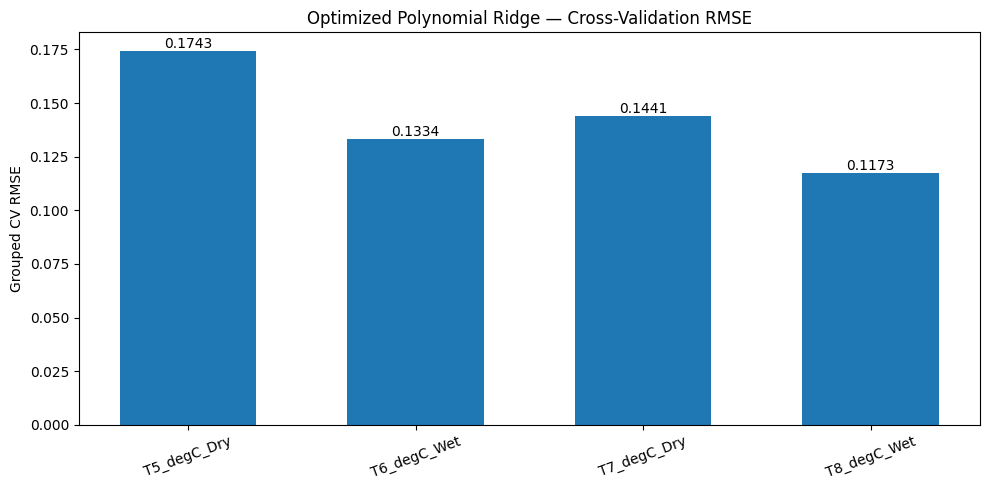


Selected hyperparameters:


,Target,Best_Degree,Best_Alpha,CV_RMSE
0,T5_degC_Dry,4,0.001,0.174287
1,T6_degC_Wet,4,0.001,0.133367
2,T7_degC_Dry,4,0.001,0.144111
3,T8_degC_Wet,4,0.001,0.117300


In [41]:
# ============================================================
# CELL 39 — TUNING SUMMARY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(tuning_df))

ax.bar(
    x,
    tuning_df['CV_RMSE'],
    width=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(tuning_df['Target'], rotation=20)
ax.set_ylabel('Grouped CV RMSE')
ax.set_title('Optimized Polynomial Ridge — Cross-Validation RMSE')

for i, value in enumerate(tuning_df['CV_RMSE']):
    ax.text(
        i,
        value,
        f'{value:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

print("\nSelected hyperparameters:")
display(tuning_df)

In [42]:
# ============================================================
# CELL 40 — FINAL GROUPED CROSS-VALIDATION
# ============================================================

from sklearn.base import clone

cv = GroupKFold(n_splits=5)

cv_predictions = np.zeros_like(Y.values, dtype=float)

fold_records = []

print("="*75)
print("FINAL TEMPERATURE-GROUP CROSS-VALIDATION")
print("="*75)

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, Y, groups=groups), start=1
):

    print(f"\nFOLD {fold}/5")

    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])

    overlap = train_groups.intersection(test_groups)

    print("Training samples :", len(train_idx))
    print("Validation samples:", len(test_idx))
    print("Training groups  :", len(train_groups))
    print("Validation groups:", len(test_groups))
    print("Group overlap    :", len(overlap))

    if len(overlap) > 0:
        raise RuntimeError("DATA LEAKAGE DETECTED!")

    for j, target in enumerate(TARGETS):

        row = tuning_df[tuning_df['Target'] == target].iloc[0]

        model = Pipeline([
            ('poly', PolynomialFeatures(
                degree=int(row['Best_Degree']),
                include_bias=False
            )),
            ('scale', StandardScaler()),
            ('ridge', Ridge(
                alpha=float(row['Best_Alpha'])
            ))
        ])

        model.fit(
            X.iloc[train_idx],
            Y.iloc[train_idx, j]
        )

        pred = model.predict(X.iloc[test_idx])

        cv_predictions[test_idx, j] = pred

    print("Fold completed.")

print("\nCross-validation complete.")

FINAL TEMPERATURE-GROUP CROSS-VALIDATION

FOLD 1/5
Training samples : 147
Validation samples: 37
Training groups  : 40
Validation groups: 9
Group overlap    : 0
Fold completed.

FOLD 2/5
Training samples : 147
Validation samples: 37
Training groups  : 40
Validation groups: 9
Group overlap    : 0
Fold completed.

FOLD 3/5
Training samples : 147
Validation samples: 37
Training groups  : 39
Validation groups: 10
Group overlap    : 0
Fold completed.

FOLD 4/5
Training samples : 147
Validation samples: 37
Training groups  : 38
Validation groups: 11
Group overlap    : 0
Fold completed.

FOLD 5/5
Training samples : 148
Validation samples: 36
Training groups  : 39
Validation groups: 10
Group overlap    : 0
Fold completed.

Cross-validation complete.


In [43]:
# ============================================================
# CELL 41 — FINAL OUT-OF-GROUP METRICS
# ============================================================

final_cv_metrics = []

for j, target in enumerate(TARGETS):

    actual = Y.iloc[:, j].values
    predicted = cv_predictions[:, j]

    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    final_cv_metrics.append({
        'Target': target,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })

final_cv_df = pd.DataFrame(final_cv_metrics)

print("="*75)
print("FINAL OUT-OF-GROUP VALIDATION PERFORMANCE")
print("="*75)

display(
    final_cv_df.style
    .format({
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    })
)

FINAL OUT-OF-GROUP VALIDATION PERFORMANCE


,Target,R2,MAE,RMSE
0,T5_degC_Dry,0.9946,0.1422,0.1756
1,T6_degC_Wet,0.9946,0.1106,0.1339
2,T7_degC_Dry,0.9929,0.1073,0.1467
3,T8_degC_Wet,0.9916,0.0950,0.1193


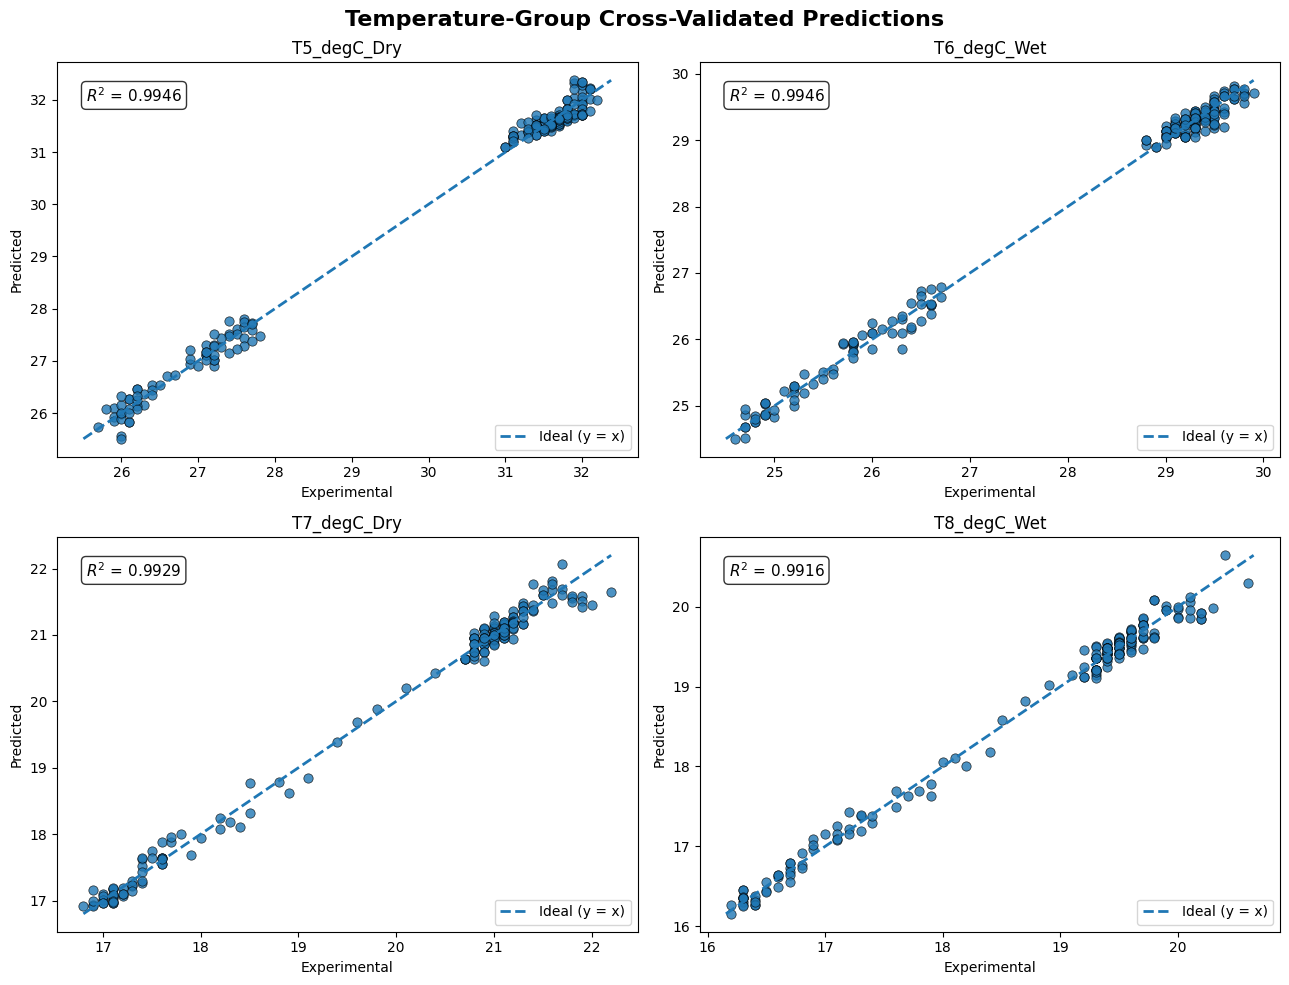

In [44]:
# ============================================================
# CELL 42 — EXPERIMENTAL VS CROSS-VALIDATED PREDICTIONS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 10)
)

axes = axes.flatten()

for j, target in enumerate(TARGETS):

    ax = axes[j]

    actual = Y.iloc[:, j].values
    predicted = cv_predictions[:, j]

    ax.scatter(
        actual,
        predicted,
        s=45,
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5
    )

    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        '--',
        linewidth=2,
        label='Ideal (y = x)'
    )

    r2 = r2_score(actual, predicted)

    ax.text(
        0.05,
        0.90,
        f'$R^2$ = {r2:.4f}',
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax.set_xlabel('Experimental')
    ax.set_ylabel('Predicted')
    ax.set_title(target)
    ax.legend()

plt.suptitle(
    'Temperature-Group Cross-Validated Predictions',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

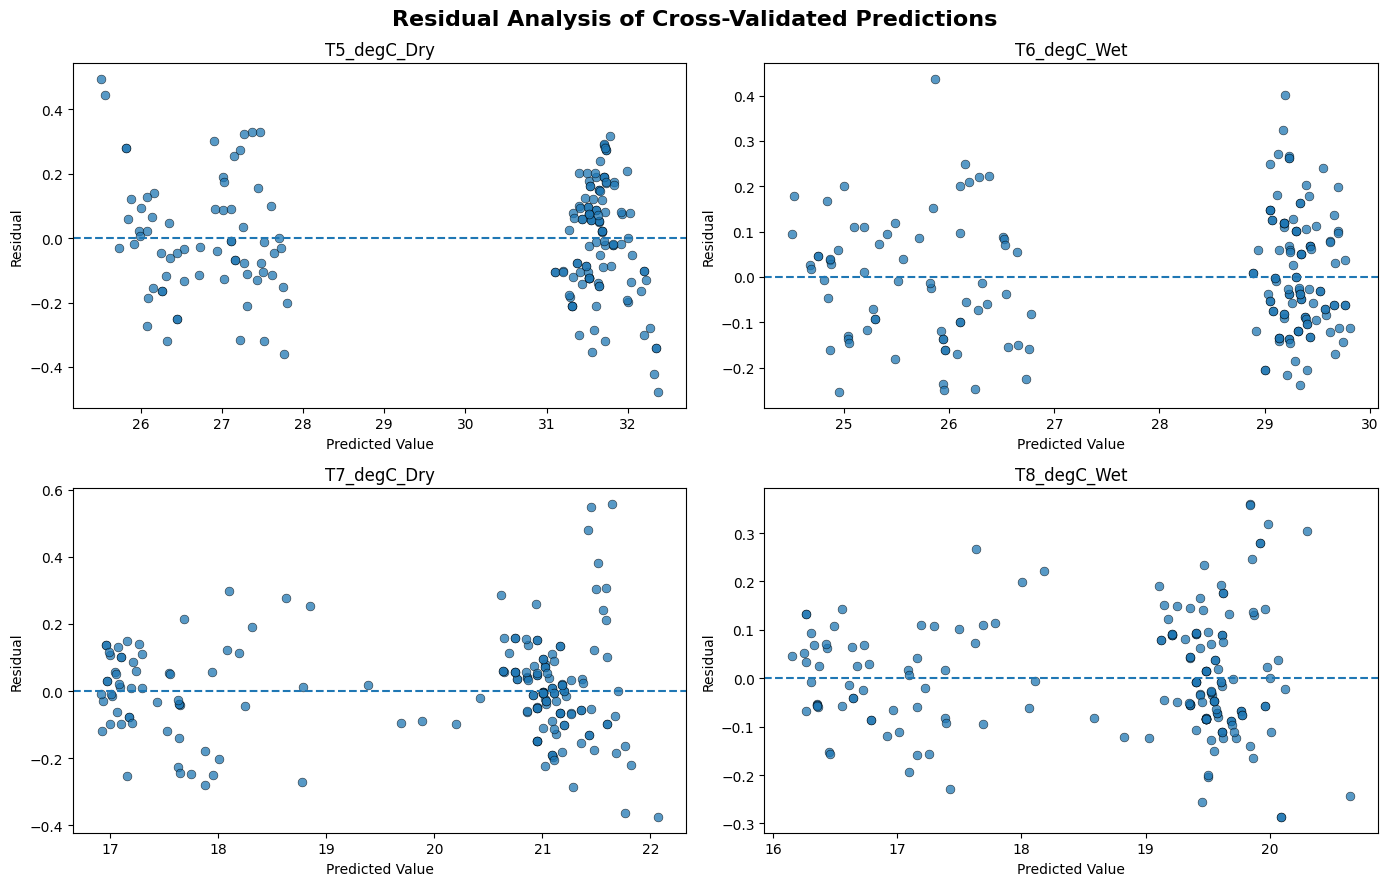

In [45]:
# ============================================================
# CELL 43 — RESIDUAL ANALYSIS
# ============================================================

residuals = Y.values - cv_predictions

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

axes = axes.flatten()

for j, target in enumerate(TARGETS):

    ax = axes[j]

    ax.scatter(
        cv_predictions[:, j],
        residuals[:, j],
        s=40,
        alpha=0.75,
        edgecolor='black',
        linewidth=0.4
    )

    ax.axhline(
        0,
        linestyle='--',
        linewidth=1.5
    )

    ax.set_xlabel('Predicted Value')
    ax.set_ylabel('Residual')
    ax.set_title(target)

plt.suptitle(
    'Residual Analysis of Cross-Validated Predictions',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

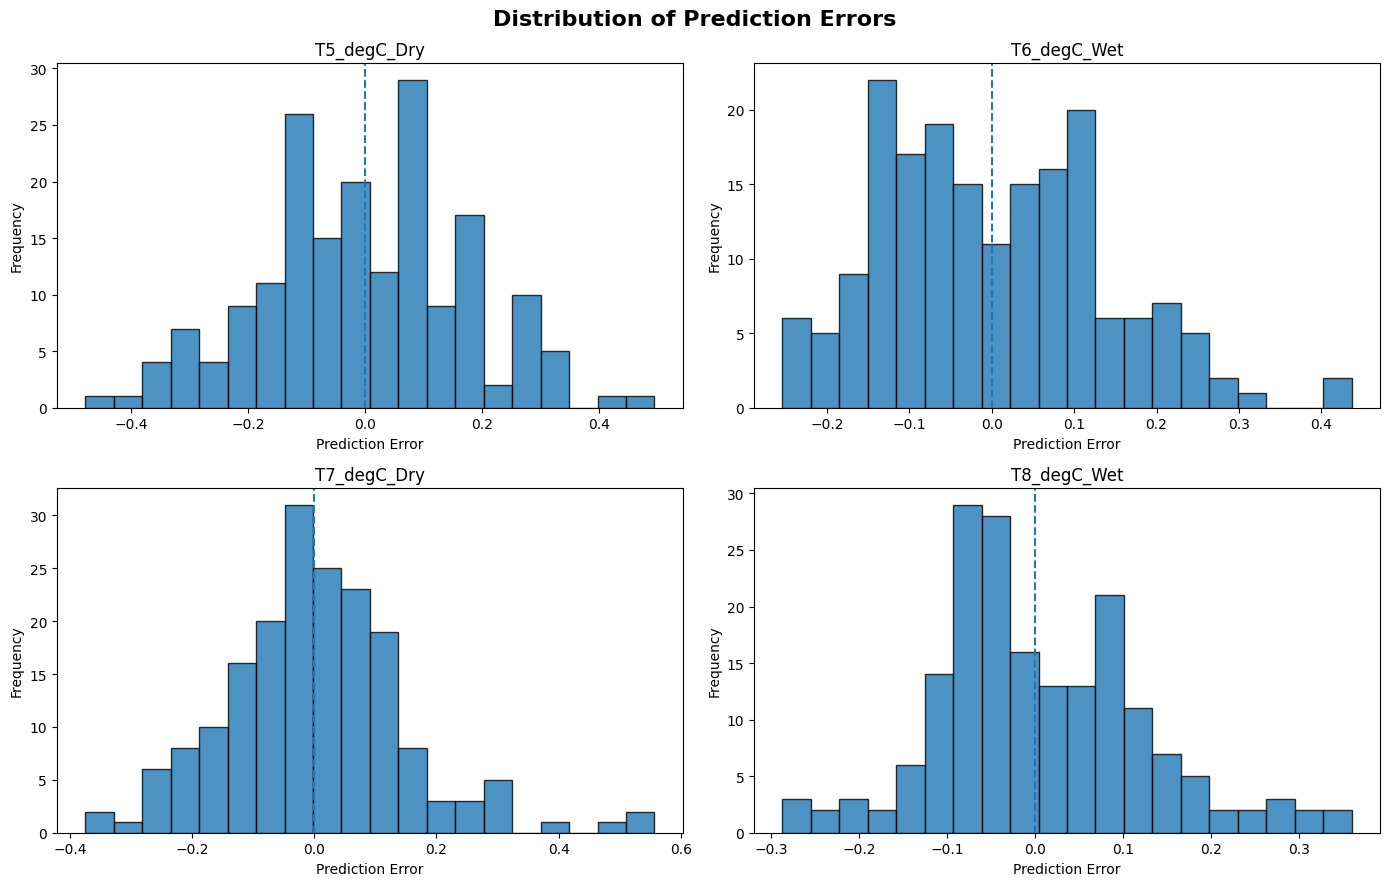

In [46]:
# ============================================================
# CELL 44 — ERROR DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

axes = axes.flatten()

for j, target in enumerate(TARGETS):

    ax = axes[j]

    ax.hist(
        residuals[:, j],
        bins=20,
        edgecolor='black',
        alpha=0.8
    )

    ax.axvline(
        0,
        linestyle='--',
        linewidth=1.5
    )

    ax.set_xlabel('Prediction Error')
    ax.set_ylabel('Frequency')
    ax.set_title(target)

plt.suptitle(
    'Distribution of Prediction Errors',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

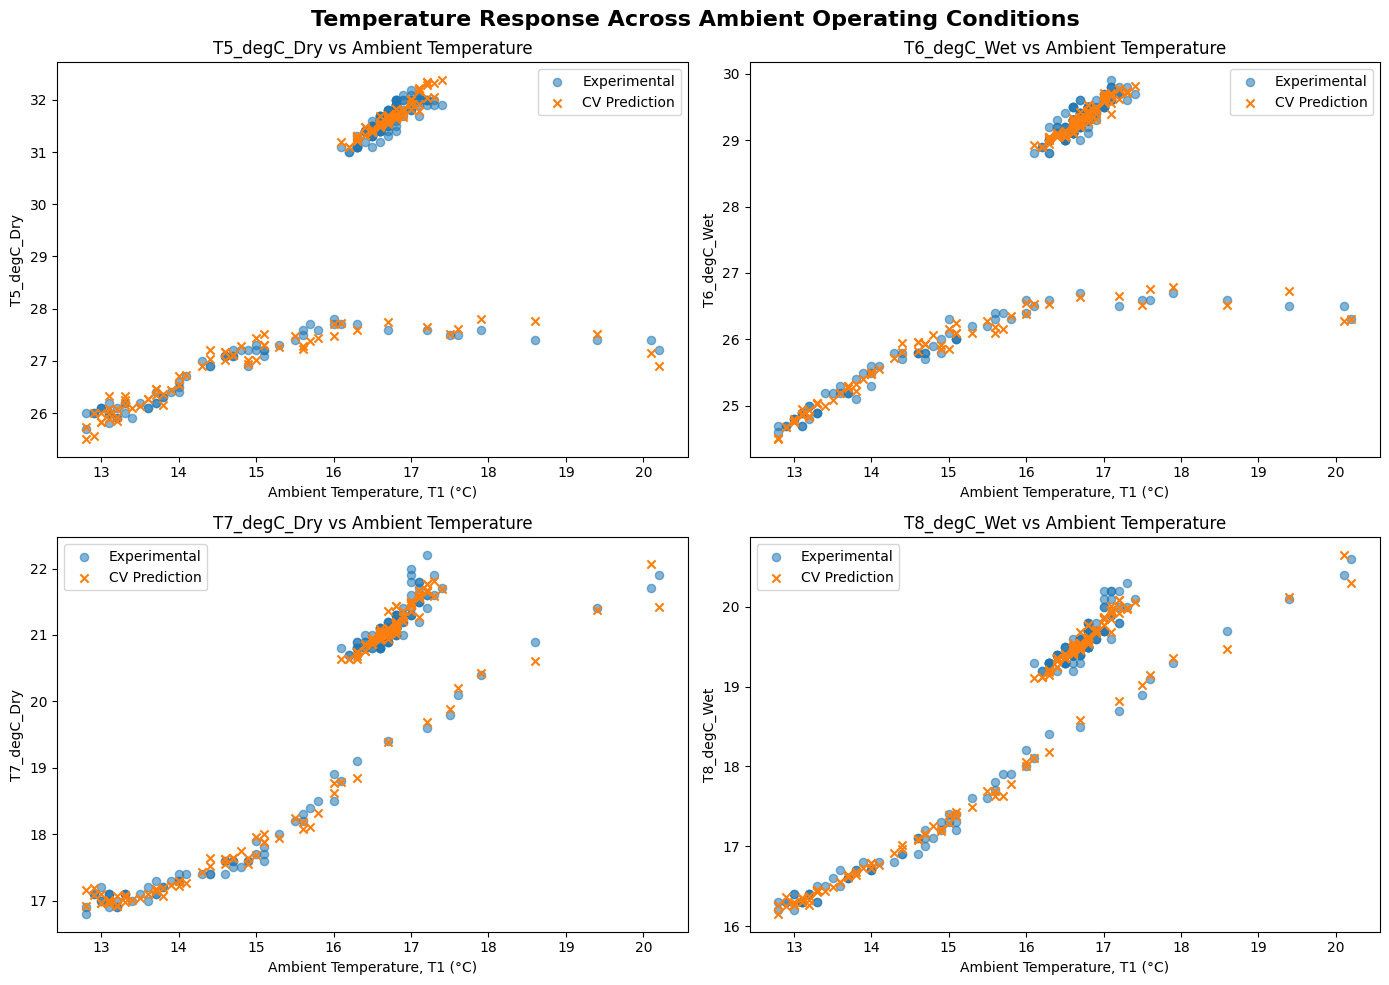

In [47]:
# ============================================================
# CELL 45 — AMBIENT TEMPERATURE RESPONSE
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

axes = axes.flatten()

sort_idx = np.argsort(df_final['T1_degC'].values)

T_ambient = df_final['T1_degC'].values

for j, target in enumerate(TARGETS):

    ax = axes[j]

    ax.scatter(
        T_ambient,
        Y.iloc[:, j],
        s=35,
        alpha=0.55,
        label='Experimental'
    )

    ax.scatter(
        T_ambient,
        cv_predictions[:, j],
        s=35,
        marker='x',
        label='CV Prediction'
    )

    ax.set_xlabel('Ambient Temperature, T1 (°C)')
    ax.set_ylabel(target)
    ax.set_title(f'{target} vs Ambient Temperature')
    ax.legend()

plt.suptitle(
    'Temperature Response Across Ambient Operating Conditions',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# CELL 46 — POLYNOMIAL RIDGE COEFFICIENT ANALYSIS
# ============================================================

print("="*75)
print("POLYNOMIAL RIDGE MODEL COEFFICIENT ANALYSIS")
print("="*75)

final_models = {}

for target in TARGETS:

    row = tuning_df[tuning_df['Target'] == target].iloc[0]

    degree = int(row['Best_Degree'])
    alpha = float(row['Best_Alpha'])

    model = Pipeline([
        ('poly', PolynomialFeatures(
            degree=degree,
            include_bias=False
        )),
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    model.fit(X, df_final[target])

    final_models[target] = model

    poly = model.named_steps['poly']
    ridge = model.named_steps['ridge']

    feature_names = poly.get_feature_names_out(FEATURES)

    coef_df = pd.DataFrame({
        'Feature_Term': feature_names,
        'Coefficient': ridge.coef_
    })

    coef_df['Absolute_Coefficient'] = (
        coef_df['Coefficient'].abs()
    )

    coef_df = coef_df.sort_values(
        'Absolute_Coefficient',
        ascending=False
    )

    print(f"\n{target}")
    print("-"*60)
    display(coef_df.head(10))

POLYNOMIAL RIDGE MODEL COEFFICIENT ANALYSIS

T5_degC_Dry
------------------------------------------------------------


,Feature_Term,Coefficient,Absolute_Coefficient
37,T1_degC^3 P2_Bar,-4.051640,4.051640
68,P2_Bar^4,-3.622779,3.622779
46,T1_degC Power_Watt^2 P2_Bar,3.170625,3.170625
4,T1_degC^2,3.093705,3.093705
5,T1_degC Power_Watt,-2.796698,2.796698
36,T1_degC^3 P1_Bar,-2.703098,2.703098
18,T1_degC Power_Watt^2,-2.674383,2.674383
40,T1_degC^2 Power_Watt P2_Bar,2.615914,2.615914
39,T1_degC^2 Power_Watt P1_Bar,2.532225,2.532225
35,T1_degC^3 Power_Watt,-2.455514,2.455514



T6_degC_Wet
------------------------------------------------------------


,Feature_Term,Coefficient,Absolute_Coefficient
68,P2_Bar^4,-2.426803,2.426803
37,T1_degC^3 P2_Bar,-2.178199,2.178199
7,T1_degC P2_Bar,2.043149,2.043149
36,T1_degC^3 P1_Bar,-1.800305,1.800305
67,P1_Bar P2_Bar^3,-1.606606,1.606606
44,T1_degC Power_Watt^3,-1.565843,1.565843
23,T1_degC P2_Bar^2,1.502673,1.502673
20,T1_degC Power_Watt P2_Bar,1.501762,1.501762
64,P1_Bar^4,1.437208,1.437208
40,T1_degC^2 Power_Watt P2_Bar,1.422234,1.422234



T7_degC_Dry
------------------------------------------------------------


,Feature_Term,Coefficient,Absolute_Coefficient
36,T1_degC^3 P1_Bar,3.113263,3.113263
64,P1_Bar^4,3.076895,3.076895
51,T1_degC P1_Bar^2 P2_Bar,-3.011884,3.011884
34,T1_degC^4,-2.803524,2.803524
52,T1_degC P1_Bar P2_Bar^2,-2.798162,2.798162
13,P2_Bar^2,2.748096,2.748096
16,T1_degC^2 P1_Bar,2.662337,2.662337
60,Power_Watt P1_Bar^3,2.624465,2.624465
2,P1_Bar,-2.436895,2.436895
33,P2_Bar^3,2.161327,2.161327



T8_degC_Wet
------------------------------------------------------------


,Feature_Term,Coefficient,Absolute_Coefficient
51,T1_degC P1_Bar^2 P2_Bar,-2.006557,2.006557
64,P1_Bar^4,1.933873,1.933873
52,T1_degC P1_Bar P2_Bar^2,-1.802862,1.802862
16,T1_degC^2 P1_Bar,1.657943,1.657943
50,T1_degC P1_Bar^3,-1.558599,1.558599
35,T1_degC^3 Power_Watt,-1.545025,1.545025
60,Power_Watt P1_Bar^3,1.520498,1.520498
13,P2_Bar^2,1.289473,1.289473
36,T1_degC^3 P1_Bar,1.266205,1.266205
17,T1_degC^2 P2_Bar,1.238564,1.238564


In [49]:
# ============================================================
# CELL 47 — FINAL MODEL + EXPORT
# ============================================================

import joblib
import os

print("="*80)
print("FINAL MODEL DEVELOPMENT COMPLETE")
print("="*80)

# ------------------------------------------------------------
# Fit final models using ALL available experimental data
# ------------------------------------------------------------

final_predictions = np.zeros_like(Y.values, dtype=float)

final_model_metrics = []

for j, target in enumerate(TARGETS):

    model = final_models[target]

    # Final model is already fitted on complete dataset
    pred = model.predict(X)

    final_predictions[:, j] = pred

    actual = Y.iloc[:, j].values

    final_model_metrics.append({
        'Target': target,
        'R2': r2_score(actual, pred),
        'MAE': mean_absolute_error(actual, pred),
        'RMSE': np.sqrt(mean_squared_error(actual, pred))
    })

final_metrics_df = pd.DataFrame(final_model_metrics)

# ------------------------------------------------------------
# Final prediction table
# ------------------------------------------------------------

final_results = df_final[FEATURES].copy()

for j, target in enumerate(TARGETS):

    final_results[f'{target}_Experimental'] = Y.iloc[:, j].values
    final_results[f'{target}_Predicted'] = final_predictions[:, j]
    final_results[f'{target}_Error'] = (
        Y.iloc[:, j].values - final_predictions[:, j]
    )

# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------

final_metrics_df.to_csv(
    'final_model_metrics.csv',
    index=False
)

tuning_df.to_csv(
    'polynomial_ridge_tuning.csv',
    index=False
)

final_results.to_csv(
    'final_temperature_predictions.csv',
    index=False
)

# ------------------------------------------------------------
# Save models
# ------------------------------------------------------------

joblib.dump(
    final_models,
    'final_polynomial_ridge_models.pkl'
)

# ------------------------------------------------------------
# Save complete package
# ------------------------------------------------------------

model_package = {
    'models': final_models,
    'features': FEATURES,
    'targets': TARGETS,
    'tuning_results': tuning_df,
    'cv_metrics': final_cv_df,
    'final_metrics': final_metrics_df
}

joblib.dump(
    model_package,
    'refrigeration_temperature_ML_model.pkl'
)

# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------

print("\nFINAL TRAINING-FIT METRICS")
print("-"*80)

display(
    final_metrics_df.style.format({
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    })
)

print("\nOUT-OF-GROUP VALIDATION METRICS")
print("-"*80)

display(
    final_cv_df.style.format({
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    })
)

print("\nFILES SAVED:")
print("1. final_model_metrics.csv")
print("2. polynomial_ridge_tuning.csv")
print("3. final_temperature_predictions.csv")
print("4. final_polynomial_ridge_models.pkl")
print("5. refrigeration_temperature_ML_model.pkl")

print("\n" + "="*80)
print("ML PIPELINE COMPLETE")
print("="*80)

FINAL MODEL DEVELOPMENT COMPLETE

FINAL TRAINING-FIT METRICS
--------------------------------------------------------------------------------


,Target,R2,MAE,RMSE
0,T5_degC_Dry,0.9962,0.1214,0.1472
1,T6_degC_Wet,0.9955,0.1005,0.1227
2,T7_degC_Dry,0.9948,0.0912,0.1251
3,T8_degC_Wet,0.9933,0.0844,0.1063



OUT-OF-GROUP VALIDATION METRICS
--------------------------------------------------------------------------------


,Target,R2,MAE,RMSE
0,T5_degC_Dry,0.9946,0.1422,0.1756
1,T6_degC_Wet,0.9946,0.1106,0.1339
2,T7_degC_Dry,0.9929,0.1073,0.1467
3,T8_degC_Wet,0.9916,0.0950,0.1193



FILES SAVED:
1. final_model_metrics.csv
2. polynomial_ridge_tuning.csv
3. final_temperature_predictions.csv
4. final_polynomial_ridge_models.pkl
5. refrigeration_temperature_ML_model.pkl

ML PIPELINE COMPLETE
